# Exploratory & Descriptive Analytics — Website (`www.parsewise.ai`)


### PostHog terms used below

- `distinct_id` vs `person_id`: `distinct_id` is the browser or device-level identifier attached to an event stream. `person_id` is PostHog's person record, which can merge multiple `distinct_id` values after identification. For this descriptive notebook, `distinct_id` is the cleanest visitor-level unit available in the export.
- `channel_type`: PostHog's high-level acquisition label for a session, such as Direct, Organic Search, Referral, or Social.
- Bounce rate: the share of sessions marked `is_bounce = True`, meaning the session contained only minimal engagement before ending.
    - is_bounce = true when three criteria are met:
        1. Spent less than 10 seconds on the page
        2. Did not autocapture any events (no clicks, etc.)
        3. Only had one pageview
- `$pageview`: an automatically captured page-load event.
- `$autocapture`: an automatically captured front-end interaction event, usually a click or field change.
- `$dead_click`: a click that appears to have had no visible result, used as a friction signal.
- `$rageclick`: repeated rapid clicking on the same area, usually interpreted as frustration or unmet expectation.
- `$pageleave`: an automatically captured event fired when the browser leaves a page.


In [ ]:
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import statsmodels.api as sm
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

try:
    display
except NameError:
    def display(obj):
        print(obj)

def Markdown(text):
    return text

try:
    import seaborn as sns
except ModuleNotFoundError:
    class _SeabornFallback:
        def set_theme(self, style="whitegrid", context="notebook", palette="muted"):
            try:
                plt.style.use("seaborn-v0_8-whitegrid")
            except OSError:
                plt.style.use("default")

        def barplot(self, data, x, y, hue=None, legend=False, ax=None, palette=None, dodge=False, color=None):
            ax = ax or plt.gca()
            values = pd.Series(data[x]).fillna(0)
            labels = pd.Series(data[y]).fillna("Unknown").astype(str)
            ax.barh(labels, values, color=color or "#4C72B0")
            return ax

        def histplot(self, data, bins=10, ax=None, color=None, discrete=False, binwidth=None):
            ax = ax or plt.gca()
            series = pd.Series(data).dropna()
            if discrete:
                start = int(series.min())
                stop = int(series.max()) + 2
                ax.hist(series, bins=range(start, stop), color=color or "#4C72B0", edgecolor="white", align="left", rwidth=0.9)
            else:
                ax.hist(series, bins=bins, color=color or "#4C72B0", edgecolor="white")
            return ax

        def countplot(self, x=None, data=None, ax=None, color=None):
            ax = ax or plt.gca()
            counts = data[x].value_counts().sort_index()
            ax.bar(counts.index.astype(str), counts.values, color=color or "#4C72B0")
            return ax

    sns = _SeabornFallback()

sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 130

REPO = Path.cwd().resolve()
if not (REPO / "utils").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

DATA_DIR = REPO / "raw data"
FIG_DIR = REPO / "outputs" / "eda_website"
FIG_DIR.mkdir(parents=True, exist_ok=True)

WEBSITE_FILE = DATA_DIR / "website-export-2026-06-05.xlsx"
print(f"File exists: {WEBSITE_FILE.exists()}")

PAGE_LABEL_MAP = {
    "/": "Home Page",
    "/get-started": "Get Started Page",
    "/platform": "Platform Page",
    "/pricing": "Pricing Page",
    "/about-us": "About Us Page",
    "/labs": "Labs Page",
    "/solutions": "Solutions Page",
    "/pde": "PDE Page",
    "/api": "API Page",
    "/pricing-platform": "Platform Pricing Page",
    "/pricing-api": "API Pricing Page",
    "/software-3.0": "Software 3.0 Page",
    "/privacy-policy": "Privacy Policy Page",
    "/terms-and-conditions": "Terms and Conditions Page",
    "/introducing-navi": "Introducing Navi Page",
    "/doc-processing-pipelines": "Doc Processing Pipelines Page",
    "/core-loop": "Core Loop Page",
    "/complex-claims": "Complex Claims Page",
    "/claim-risk": "Claim Risk Page",
    "/mna-dd": "M&A DD Page",
    "/risk-insights": "Risk Insights Page",
    "/loss-fund-reconciliation": "Loss Fund Reconciliation Page",
    "/fund-diligence": "Fund Diligence Page",
    "/portfolio-monitoring": "Portfolio Monitoring Page",
    "/company-diligence": "Company Diligence Page",
    "/mortgage-validation": "Mortgage Validation Page",
    "/kyc-aml": "KYC AML Page",
    "/lp-reporting": "LP Reporting Page",
    "/ux-design-for-agent-workflows": "UX Design for Agent Workflows Page",
    "/slush": "Slush Page",
    "/recovery": "Recovery Page",
}

def pretty_page(pathname):
    if pd.isna(pathname):
        return "Unknown"
    return PAGE_LABEL_MAP.get(pathname, pathname)




# ── Dissertation figure house style ──────────────────────────────────────────
STEEL = "#4C72B0"   # neutral single-hue bars / lines
DUSTY = "#C44E52"   # friction / negative emphasis
# seaborn "muted" order: blue, orange, green, red, purple, brown, pink, grey, yellow, cyan
MUTED = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2",
         "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD"]

def tidy_axes(ax, orient="v"):
    """House style for an Axes: light grey gridlines on the value axis only,
    a de-spined frame and a normal-weight title."""
    ax.set_axisbelow(True)
    if orient == "v":            # vertical bars / line charts -> horizontal gridlines
        ax.grid(axis="y", color="0.85", linewidth=0.8)
        ax.grid(axis="x", visible=False)
    else:                         # horizontal bars -> vertical gridlines
        ax.grid(axis="x", color="0.85", linewidth=0.8)
        ax.grid(axis="y", visible=False)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("0.6")
    if ax.get_title():
        ax.set_title(ax.get_title(), fontweight="normal")
    return ax


### Data loading & cleaning

The cleaning steps below keep the notebook self-contained and make the session-level metrics line up better with the cleaned event data.

- Parse the event and session time columns into proper UTC datetimes at the start.
- Remove staging traffic by filtering out any events from `framer.app`.
- Remove tracked page paths that are now inactive on the live site, including legacy `404` pages such as `/old-get-started`, `/old_about`, `/old_platform`, `/r/US4RXMMVCTKITJ`, and `/dQw_ekSE`.
- Remove excluded non-core paths such as `Collections Intelligence` so they do not distort the website analysis.
- Restrict the sessions table to session IDs that still have at least one remaining cleaned event after those path filters.
- Split out `$autocapture` events before cleaning them.
- Remove repeated `$autocapture` events that fire again within 2 seconds for the same session and page element.
- Keep the first real interaction and drop the extra repeated clicks.
- Pull out `join@parsewise.ai` mailto clicks on `/about-us` so that specific careers email CTA does not get mixed into the main website behaviour data.
- Add the cleaned `$autocapture` events back together with the other events.
- Recalculate session `pageview_count` and `unique_urls_visited` from the cleaned `$pageview` events so the session metrics used later in the notebook match the cleaned event table.
- Exclude zero-pageview sessions from the pageviews-per-session chart so that distribution reflects only sessions with at least one observed cleaned `$pageview` event.
- Sort the cleaned events by time and tidy the index.
- Check the final row counts, visitor counts, session counts, zero-pageview sessions, and date range to make sure the cleaned data still looks right.


In [2]:
# ── Load sheets from June 2026 export ────────────────────────────────────────
_event_master = pd.read_excel(WEBSITE_FILE, sheet_name="event_master")
_sess_summary  = pd.read_excel(WEBSITE_FILE, sheet_name="sessions_summary")
_persons2      = pd.read_excel(WEBSITE_FILE, sheet_name="persons 2")

# Rename event_master columns to match legacy names used throughout notebook
_event_master = _event_master.rename(columns={
    "event_type":     "ac_event_type",
    "elements_chain": "ac_elements_chain",
    "element_text":   "ac_element_text",
    "element_href":   "ac_href",
})
_event_master["event_timestamp"] = pd.to_datetime(
    _event_master["event_timestamp"], utc=True, format="mixed", errors="coerce"
)
_event_master["date"] = _event_master["event_timestamp"].dt.normalize()
web_events = _event_master

# Rename sessions columns to match legacy names used throughout notebook
_sess_summary = _sess_summary.rename(columns={
    "start_timestamp":          "session_start",
    "end_timestamp":            "session_end",
    "session_duration_seconds": "duration_seconds",
    "entry_pathname":           "landing_pathname",
    "entry_referring_domain":   "referring_domain",
})
_sess_summary["session_start"] = pd.to_datetime(
    _sess_summary["session_start"], utc=True, format="mixed", errors="coerce"
)
_sess_summary["session_end"] = pd.to_datetime(
    _sess_summary["session_end"], utc=True, format="mixed", errors="coerce"
)

# Derive channel_type from referring_domain
# PostHog's channel_type property is unpopulated in this export — reconstruct it
_SEARCH_DOMAINS   = {"google", "bing", "yahoo", "duckduckgo", "baidu", "yandex", "ecosia"}
_SOCIAL_DOMAINS   = {"linkedin", "t.co", "twitter", "x.com", "facebook", "instagram",
                     "youtube", "tiktok", "reddit", "lnkd.in"}
_REFERRAL_DOMAINS = {"producthunt", "ycombinator", "news.ycombinator", "github",
                     "substack", "medium", "dev.to", "indiehackers"}

def _classify_channel(domain):
    if pd.isna(domain) or str(domain).strip() in ("", "nan"):
        return "Direct"
    d = str(domain).lower().replace("www.", "")
    root = d.split(".")[0]
    if root in _SEARCH_DOMAINS or "google" in d:
        return "Organic Search"
    if root in _SOCIAL_DOMAINS or d in _SOCIAL_DOMAINS:
        return "Organic Social"
    if root in _REFERRAL_DOMAINS:
        return "Referral"
    return "Referral"

_sess_summary["channel_type"] = _sess_summary["referring_domain"].apply(_classify_channel)

# Join unique_urls_visited from persons 2 via distinct_id → person_id bridge
_id_bridge = (
    _event_master[["distinct_id", "person_id"]]
    .dropna(subset=["person_id"])
    .drop_duplicates("distinct_id")
)
_p2_cols = _persons2[["person_id", "unique_urls_visited", "country", "device_type", "browser"]].copy()
web_sessions = (
    _sess_summary
    .merge(_id_bridge, on="distinct_id", how="left")
    .merge(_p2_cols,   on="person_id",   how="left")
    .drop(columns=["person_id"])
)

def deduplicate_autocapture_windows(df, timestamp_col, session_col, element_cols, window_seconds=2):
    working = df.copy()
    working[timestamp_col] = pd.to_datetime(working[timestamp_col], utc=True, errors="coerce")
    sort_cols = [session_col, *element_cols, timestamp_col]
    working = working.sort_values(sort_cols).reset_index(drop=False).rename(columns={"index": "_original_index"})
    deltas = (
        working.groupby([session_col, *element_cols], dropna=False)[timestamp_col]
        .diff()
        .dt.total_seconds()
    )
    keep_mask = deltas.isna() | (deltas > window_seconds)
    return working.loc[keep_mask].sort_values("_original_index").drop(columns="_original_index").copy()

INACTIVE_PATHS = {
    "/dQw_ekSE",
    "/old-get-started",
    "/old_about",
    "/old_platform",
    "/r/US4RXMMVCTKITJ",
    "/collections-intelligence",
}

framer_mask = web_events["host"].fillna("").str.contains("framer.app")
print(f"Staging events removed (framer.app): {framer_mask.sum()}")
web_events = web_events.loc[~framer_mask].copy()

inactive_path_mask = web_events["pathname"].isin(INACTIVE_PATHS)
print(f"Inactive-path events removed: {inactive_path_mask.sum()}")
web_events = web_events.loc[~inactive_path_mask].copy()

autocapture_raw = web_events.loc[web_events["event"] == "$autocapture"].copy()
web_non_autocapture = web_events.loc[web_events["event"] != "$autocapture"].copy()
web_autocapture = deduplicate_autocapture_windows(
    autocapture_raw,
    timestamp_col="event_timestamp",
    session_col="session_id",
    element_cols=["pathname", "ac_event_type", "ac_elements_chain", "ac_element_text", "ac_href"],
    window_seconds=2,
)
print(f"Autocapture rows before de-duplication: {len(autocapture_raw):,}")
print(f"Autocapture rows after de-duplication:  {len(web_autocapture):,}")
print(f"Autocapture rows removed:               {len(autocapture_raw) - len(web_autocapture):,}")

join_email_clicks = web_autocapture.loc[
    (web_autocapture["pathname"] == "/about-us")
    & web_autocapture["ac_href"].fillna("").str.contains("mailto:join@parsewise.ai", regex=False)
].copy()

web_autocapture = web_autocapture.drop(join_email_clicks.index).copy()
web_events = (
    pd.concat([web_non_autocapture, web_autocapture], ignore_index=True)
    .sort_values("event_timestamp")
    .reset_index(drop=True)
)

active_session_ids = set(web_events["session_id"].dropna())
removed_sessions = (~web_sessions["session_id"].isin(active_session_ids)).sum()
web_sessions = web_sessions.loc[web_sessions["session_id"].isin(active_session_ids)].copy()
print(f"Sessions removed after inactive/staging filtering: {removed_sessions:,}")

print(f"join@parsewise.ai mailto clicks kept separately: {len(join_email_clicks):,}")
print(f"Events sheet after cleaning: {len(web_events):,} rows")
print(f"Sessions sheet: {len(web_sessions):,} rows")
print(f"Unique visitors in events: {web_events['distinct_id'].nunique():,}")
print(f"Unique visitors in sessions: {web_sessions['distinct_id'].nunique():,}")
print(f"Date range: {web_events['event_timestamp'].min().date()} to {web_events['event_timestamp'].max().date()}")
print(f"channel_type distribution:\n{web_sessions['channel_type'].value_counts().to_string()}")

Staging events removed (framer.app): 0
Inactive-path events removed: 45
Autocapture rows before de-duplication: 24,527
Autocapture rows after de-duplication:  12,162
Autocapture rows removed:               12,365
Sessions removed after inactive/staging filtering: 5
join@parsewise.ai mailto clicks kept separately: 0
Events sheet after cleaning: 46,705 rows
Sessions sheet: 10,462 rows
Unique visitors in events: 7,925
Unique visitors in sessions: 7,925
Date range: 2026-02-26 to 2026-06-05
channel_type distribution:
channel_type
Referral          8564
Organic Search    1317
Organic Social     581


### Headline summary table

Data scale and coverage for the cleaned website export.

In [ ]:
# Headline summary table (data scale and coverage)
web_headline = pd.DataFrame({
    "Metric": ["Unique visitors", "Session rows", "Event rows (cleaned)", "Distinct event users",
               "Session date range", "Event date range"],
    "Value": [
        f"{web_sessions['distinct_id'].nunique():,}",
        f"{len(web_sessions):,}",
        f"{len(web_events):,}",
        f"{web_events['distinct_id'].nunique():,}",
        f"{web_sessions['session_start'].min():%Y-%m-%d} \u2192 {web_sessions['session_start'].max():%Y-%m-%d}",
        f"{web_events['event_timestamp'].min():%Y-%m-%d} \u2192 {web_events['event_timestamp'].max():%Y-%m-%d}",
    ],
})
display(web_headline)
web_headline.to_csv(FIG_DIR / "00_website_headline_summary.csv", index=False)


### Headline traffic summary

Bounce rate is shown as a formatted percentage, while counts and medians remain numeric so the notebook can display them cleanly without mixing strings and numbers in one column.


In [3]:
total_visitors = web_events["distinct_id"].nunique()

traffic_summary_numeric = pd.DataFrame(
    {
        "Metric": [
            "Total sessions",
            "Unique visitors",
            "Total events",
            "Median session duration (s)",
            "Mean session duration (s)",
            "Median pageviews per session",
            "Mean pageviews per session",
            "Median unique pages per session",
        ],
        "Value": [
            len(web_sessions),
            web_sessions["distinct_id"].nunique(),
            len(web_events),
            web_sessions["duration_seconds"].median(),
            round(web_sessions["duration_seconds"].mean(), 1),
            web_sessions["pageview_count"].median(),
            round(web_sessions["pageview_count"].mean(), 2),
            web_sessions["unique_urls_visited"].median(),
        ],
    }
)
traffic_summary_formatted = pd.DataFrame(
    {
        "Metric": ["Bounce rate"],
        "Value": [f"{web_sessions['is_bounce'].mean() * 100:.1f}%"],
    }
)

print("Numeric metrics")
display(traffic_summary_numeric)
print("Formatted metrics")
display(traffic_summary_formatted)


Numeric metrics


,Metric,Value
0,Total sessions,10462.00
1,Unique visitors,7925.00
2,Total events,46705.00
3,Median session duration (s),7.00
4,Mean session duration (s),195.50
5,Median pageviews per session,1.00
6,Mean pageviews per session,1.39
7,Median unique pages per session,1.00


Formatted metrics


,Metric,Value
0,Bounce rate,10.2%


## 2. Traffic sources

The chart below focuses on referring domains only. This keeps the traffic-source section simpler by showing the exact domains that sent visitors to the site, rather than mixing domain-level and channel-level views together.


In [ ]:
# ── Top referring domains ────────────────────────────────────────────────────
# Fold app / android referrer variants into their parent domain and tidy labels
# so the shortener and mobile-app hosts do not fragment the real channels.
def clean_referrer(d):
    if pd.isna(d) or str(d).strip().lower() in ("", "$direct", "nan", "direct"):
        return "Direct"
    d = str(d).strip().lower().replace("www.", "")
    if "linkedin" in d or d.startswith("lnkd"):   # linkedin.com + com.linkedin.android
        return "linkedin.com"
    if "google" in d:                             # google.com + com.google.android.gm
        return "google.com"
    if d in ("t.co", "x.co", "x.com") or "twitter" in d:   # X / Twitter shortener
        return "X.com"
    if "producthunt" in d:
        return "producthunt.com"
    if "ycombinator" in d:
        return "ycombinator.com"
    if "parsewise" in d:
        return "parsewise.ai"
    if d == "slush.org":
        return "slush.org (event)"
    return d

referrers = (
    web_sessions["referring_domain"]
    .map(clean_referrer)
    .value_counts()
    .head(10)
    .reset_index()
)
referrers.columns = ["Referring domain", "Sessions"]
display(referrers)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=referrers, x="Sessions", y="Referring domain", color=STEEL, ax=ax)
ax.set_title("Top referring domains")
ax.set_xlabel("Sessions")
ax.set_ylabel("")
tidy_axes(ax, orient="h")

fig.tight_layout()
fig.savefig(FIG_DIR / "01_traffic_sources.png", dpi=150, bbox_inches="tight")
plt.show()


### What this shows

- Most website traffic comes from direct visits, with Google as the next biggest external source.
- LinkedIn also appears as an important source of traffic, but at a much lower level than direct traffic and Google.

### What this means for the findings

- The website seems to rely heavily on brand awareness, direct visits, and private sharing, rather than only on search or social discovery.
- Search and LinkedIn still matter, but they are supporting sources rather than the main driver of traffic.


## 3. Daily activity

Daily activity is plotted as a line chart with true datetime ticks. Vertical reference lines show major Parsewise moments so traffic spikes can be read in context rather than in isolation.


In [ ]:
web_events["date"] = web_events["event_timestamp"].dt.floor("D")
daily = (
    web_events.groupby("date")
    .agg(
        events=("event", "count"),
        visitors=("distinct_id", "nunique"),
        sessions=("session_id", "nunique"),
    )
    .reset_index()
)
display(daily)

milestones = [
    (pd.Timestamp("2026-02-26", tz="UTC"), "Navi LinkedIn Launch – 26 Feb 2026",              MUTED[2]),
    (pd.Timestamp("2026-03-05", tz="UTC"), "Parsewise Product Hunt Launch – 5 Mar 2026",        MUTED[1]),
    (pd.Timestamp("2026-03-26", tz="UTC"), "LinkedIn Risk Workflow Week – 26 Mar 2026",         MUTED[4]),
    (pd.Timestamp("2026-05-26", tz="UTC"), "LinkedIn and Product Hunt API Launch – 26 May 2026", MUTED[3]),
]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(daily["date"], daily["visitors"], color=STEEL, linewidth=1.8, marker="o", markersize=3, label="Daily unique visitors")
ax.set_title("Daily unique visitors (2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Visitors")

for when, label, color in milestones:                    # social-media / launch markers
    ax.axvline(when, color=color, linestyle="--", linewidth=1.2, alpha=0.9, label=label)
# Legend placed outside the axes so it never covers the series
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0),
          frameon=True, edgecolor="0.6", facecolor="white", framealpha=1)

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator, show_offset=False))
ax.set_xlim(daily["date"].min() - pd.Timedelta(days=1), daily["date"].max() + pd.Timedelta(days=1))
tidy_axes(ax, orient="v")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_daily_visitors.png", dpi=150, bbox_inches="tight")
plt.show()


### Traffic sources over time

The daily-visitor series above shows *when* attention arrives; splitting the same timeline by acquisition source shows *which channel* each launch lights up — and how quickly each burst decays back to the direct-dominated baseline.

In [ ]:
# ── Weekly unique visitors by acquisition source ─────────────────────────────
# Same source grouping as the "Top referring domains" chart, on a linear scale,
# with posting / launch dates marked. Muted house palette for consistency.
from matplotlib.lines import Line2D

def source_group(d):
    if pd.isna(d) or str(d).strip().lower() in ("", "$direct", "nan", "direct"):
        return "Direct"
    d = str(d).strip().lower().replace("www.", "")
    if "google" in d: return "Google"
    if "linkedin" in d or d.startswith("lnkd"): return "LinkedIn"
    if "producthunt" in d: return "Product Hunt"
    if d in ("t.co", "x.co", "x.com") or "twitter" in d: return "X.com"
    if "ycombinator" in d: return "Y Combinator"
    return "Other"

SRC_ORDER = ["Direct", "Google", "LinkedIn", "Product Hunt", "X.com", "Y Combinator", "Other"]
SRC_COL = dict(zip(SRC_ORDER, MUTED))
milestones_src = [
    (pd.Timestamp("2026-02-26"), "Navi LinkedIn Launch – 26 Feb 2026"),
    (pd.Timestamp("2026-03-05"), "Parsewise Product Hunt Launch – 5 Mar 2026"),
    (pd.Timestamp("2026-03-26"), "LinkedIn Risk Workflow Week – 26 Mar 2026"),
    (pd.Timestamp("2026-05-26"), "LinkedIn and Product Hunt API Launch – 26 May 2026"),
]

_w = web_sessions.copy()
_w["source"] = _w["referring_domain"].map(source_group)
_w["week"] = _w["session_start"].dt.tz_localize(None).dt.to_period("W").dt.start_time
wk_source = _w.groupby(["week", "source"])["distinct_id"].nunique().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for s in SRC_ORDER:
    d = wk_source[wk_source["source"] == s]
    if not d.empty:
        ax.plot(d["week"], d["distinct_id"], marker="o", ms=4, lw=1.8, color=SRC_COL[s], label=s)
for when, _lab in milestones_src:
    ax.axvline(when, color="0.75", ls="--", lw=1.0, zorder=0)

ax.set_title("Weekly unique visitors by acquisition source (2026)")
ax.set_xlabel("Week")
ax.set_ylabel("Unique visitors per week")
ax.margins(x=0.01)
_loc = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(_loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(_loc, show_offset=False))
tidy_axes(ax, orient="v")

_src_h = [Line2D([0], [0], color=SRC_COL[s], marker="o", ms=4, lw=1.8, label=s) for s in SRC_ORDER]
_mile_h = [Line2D([0], [0], color="0.75", ls="--", lw=1.0, label=lab) for _, lab in milestones_src]
_box = dict(frameon=True, edgecolor="0.6", facecolor="white", framealpha=1)
_leg1 = ax.legend(handles=_src_h, title="Acquisition source", fontsize=8, title_fontsize=8.5,
                  loc="upper left", bbox_to_anchor=(1.01, 1.0), alignment="left", **_box)
ax.add_artist(_leg1)
ax.legend(handles=_mile_h, title="Posting / launch dates", fontsize=8, title_fontsize=8.5,
          loc="upper left", bbox_to_anchor=(1.01, 0.60), alignment="left", **_box)
fig.tight_layout()
fig.savefig(FIG_DIR / "07b_source_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── Daily unique visitors: Direct vs all other sources combined ──────────────
# Two lines only. Direct against every other acquisition source combined, so the
# earned/marketing traffic reads as one series against the direct baseline. Counts
# are unique visitors per day within each group (a visitor active on the same day
# via both groups counts in both). Reuses source_group / milestones_src from above.
from matplotlib.lines import Line2D

_wd = web_sessions.copy()
_wd["source"] = _wd["referring_domain"].map(source_group)
_wd["day"] = _wd["session_start"].dt.tz_localize(None).dt.floor("D")
_wd["grp"] = np.where(_wd["source"] == "Direct", "Direct", "All other sources")
alldays = pd.date_range(_wd["day"].min(), _wd["day"].max(), freq="D")
grp_daily = _wd.groupby(["day", "grp"])["distinct_id"].nunique().reset_index(name="visitors")

GRP_ORDER = ["Direct", "All other sources"]
GRP_COL = {"Direct": STEEL, "All other sources": "#DD8452"}

fig, ax = plt.subplots(figsize=(10, 5))
for grp in GRP_ORDER:
    d = (grp_daily[grp_daily["grp"] == grp]
         .set_index("day")["visitors"].reindex(alldays, fill_value=0))
    ax.plot(d.index, d.values, marker="o", ms=2.5, lw=1.5, color=GRP_COL[grp], label=grp)
for when, _lab in milestones_src:
    ax.axvline(when, color="0.75", ls="--", lw=1.0, zorder=0)

ax.set_title("Daily unique visitors, Direct vs all other sources (2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Unique visitors per day")
ax.margins(x=0.01)
_loc = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(_loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(_loc, show_offset=False))
tidy_axes(ax, orient="v")

_grp_h = [Line2D([0], [0], color=GRP_COL[g], marker="o", ms=4, lw=1.8, label=g) for g in GRP_ORDER]
_mile_h = [Line2D([0], [0], color="0.75", ls="--", lw=1.0, label=lab) for _, lab in milestones_src]
_box = dict(frameon=True, edgecolor="0.6", facecolor="white", framealpha=1)
_leg1 = ax.legend(handles=_grp_h, title="Acquisition source", fontsize=8, title_fontsize=8.5,
                  loc="upper left", bbox_to_anchor=(1.01, 1.0), alignment="left", **_box)
ax.add_artist(_leg1)
ax.legend(handles=_mile_h, title="Posting / launch dates", fontsize=8, title_fontsize=8.5,
          loc="upper left", bbox_to_anchor=(1.01, 0.78), alignment="left", **_box)
fig.tight_layout()
fig.savefig(FIG_DIR / "07c_source_over_time_daily.png", dpi=150, bbox_inches="tight")
plt.show()


### What this shows

- Website traffic peaks sharply around the early launch period and then settles into a much lower baseline.
- The red milestone lines help show whether major launches or posting activity line up with visible changes in daily visitors.

### What this means for the findings

- Launch moments appear to have been the clearest driver of short-term traffic spikes.
- Outside those periods, the site seems to receive a steadier but much smaller flow of visitors.


**More meaningful dates / exact dates - LinkedIn posts**

1. Parsewise Labs Launch on LinkedIn - 05/12/2025 (5th December 2025)
2. Parsewisew data engine launch - 15/12/2025
3. Navi Launch - 26/02/2026 - 26th Feb 2026
   - Parsewise and Navi launch on Product Hunt - 5/03/26
4. Risk Workflow week (posting 5 risk workflows for a week, 1 a day) - 26/03/2026 - 26th march
5. Announcement that Databricks had partnered with parsewise
6. API launch - 26/05/2026 - 26th May 2026
   - Also launched on Product Hunt the same day


## 4. Geography & devices

Device split is shown as a horizontal bar chart rather than a pie chart so the comparison is easier to read in print and in the final dissertation.


,Country,Unique visitors
0,United States,3419
1,India,757
2,United Kingdom,666
3,Germany,280
4,Switzerland,238
...,...,...
125,Puerto Rico,1
126,Madagascar,1
127,New Caledonia,1
128,Nicaragua,1


,Device,Unique visitors,% of visitors
0,Desktop,6299,79.4
1,Mobile,1608,20.3
2,Tablet,24,0.3


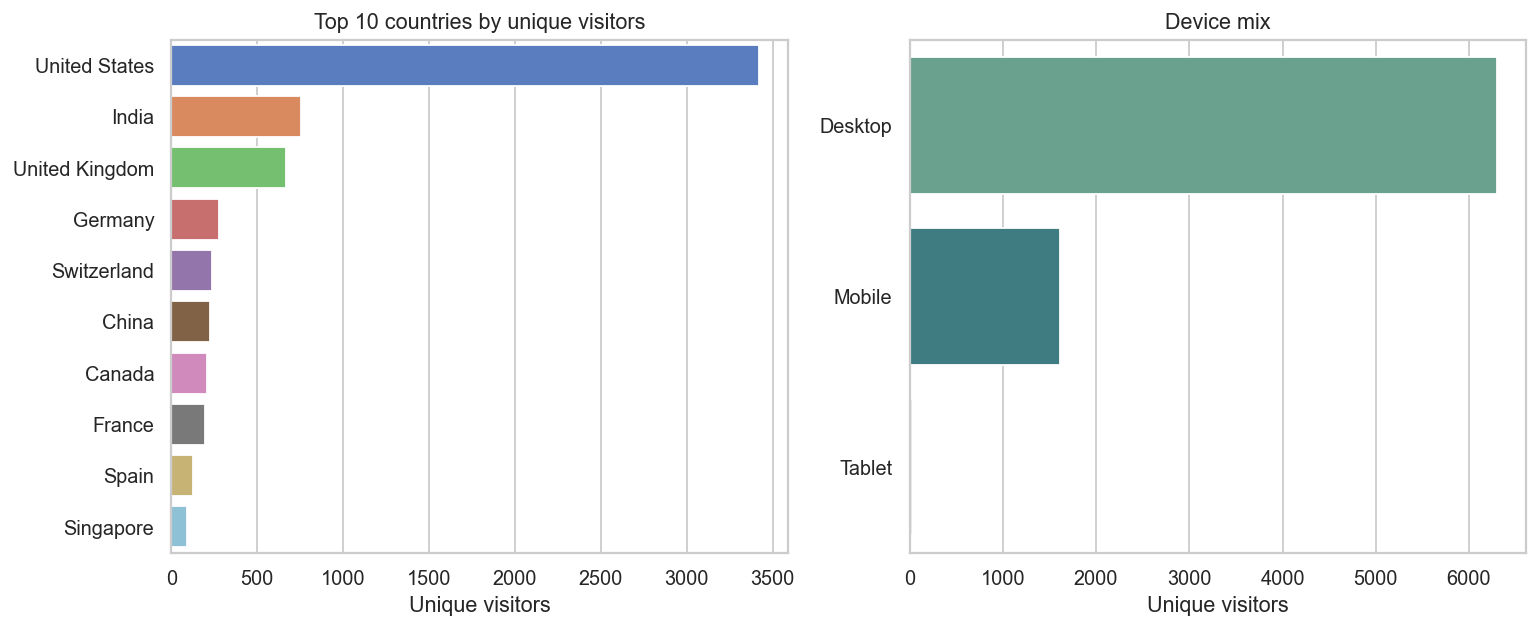

In [6]:
countries = (
    web_events.groupby("country")["distinct_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)
countries.columns = ["Country", "Unique visitors"]
display(countries)

devices = (
    web_events.groupby("device_type")["distinct_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)
devices.columns = ["Device", "Unique visitors"]
devices["% of visitors"] = (devices["Unique visitors"] / devices["Unique visitors"].sum() * 100).round(1)
display(devices)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=countries.head(10),
    x="Unique visitors",
    y="Country",
    hue="Country",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Top 10 countries by unique visitors")
axes[0].set_xlabel("Unique visitors")
axes[0].set_ylabel("")

sns.barplot(
    data=devices,
    x="Unique visitors",
    y="Device",
    hue="Device",
    legend=False,
    ax=axes[1],
    palette="crest",
)
axes[1].set_title("Device mix")
axes[1].set_xlabel("Unique visitors")
axes[1].set_ylabel("")

fig.tight_layout()
fig.savefig(FIG_DIR / "06_geo_devices.png", dpi=150, bbox_inches="tight")
plt.show()


### What this shows

- The geography table shows which countries contribute the most unique visitors.
- The device chart shows whether visitors are mainly arriving on desktop or mobile.

### What this means for the findings

- This helps describe the practical audience profile of the website rather than only the volume of visits.
- If one device type clearly dominates, that suggests where the website experience matters most.


## 5. Session duration & engagement


### Sessions per visitor

This view asks a simple descriptive question: how many times did the same visitor come back to the site during the observed window?


,Sessions,Visitors,% of visitors
0,1,6859,86.5
1,2,671,8.5
2,3,171,2.2
3,4,82,1.0
4,5,38,0.5
5,6,30,0.4
6,7,17,0.2
7,8,11,0.1
8,9,6,0.1
9,10,6,0.1


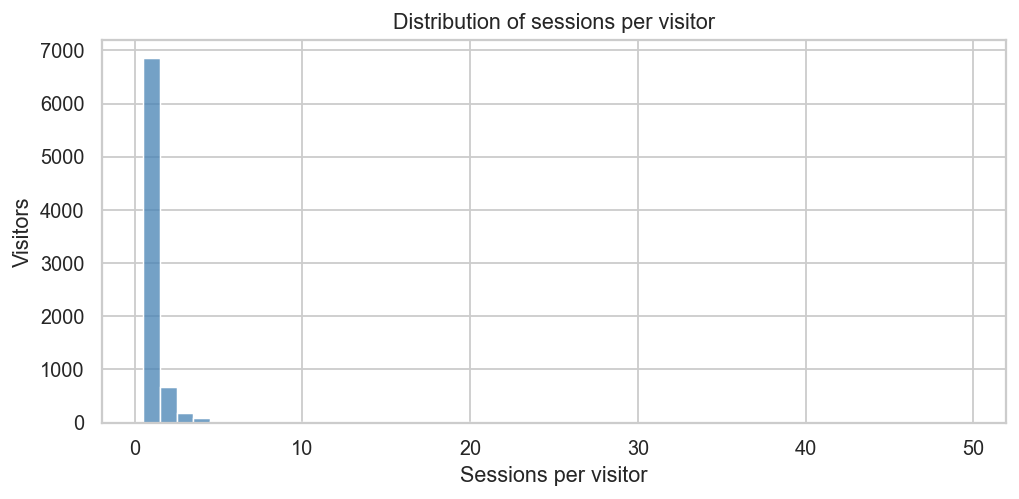

In [7]:
sessions_per_visitor = (
    web_sessions.groupby("distinct_id")
    .size()
    .rename("sessions")
    .reset_index()
)
session_frequency = (
    sessions_per_visitor["sessions"]
    .value_counts()
    .sort_index()
    .rename_axis("Sessions")
    .reset_index(name="Visitors")
)
session_frequency["% of visitors"] = (
    session_frequency["Visitors"] / session_frequency["Visitors"].sum() * 100
).round(1)
display(session_frequency.head(15))

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(sessions_per_visitor["sessions"], discrete=True, binwidth=1, ax=ax, color="steelblue")
ax.set_title("Distribution of sessions per visitor")
ax.set_xlabel("Sessions per visitor")
ax.set_ylabel("Visitors")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_sessions_per_visitor.png", dpi=150, bbox_inches="tight")
plt.show()


### What this shows

- Many visitors only have one session, while fewer visitors return multiple times.
- The distribution makes it easy to see whether repeat visits are common or rare.

### What this means for the findings

- The website appears to attract many one-off visits, with a smaller group of returning visitors.
- This suggests repeat engagement exists, but it is not the dominant pattern.


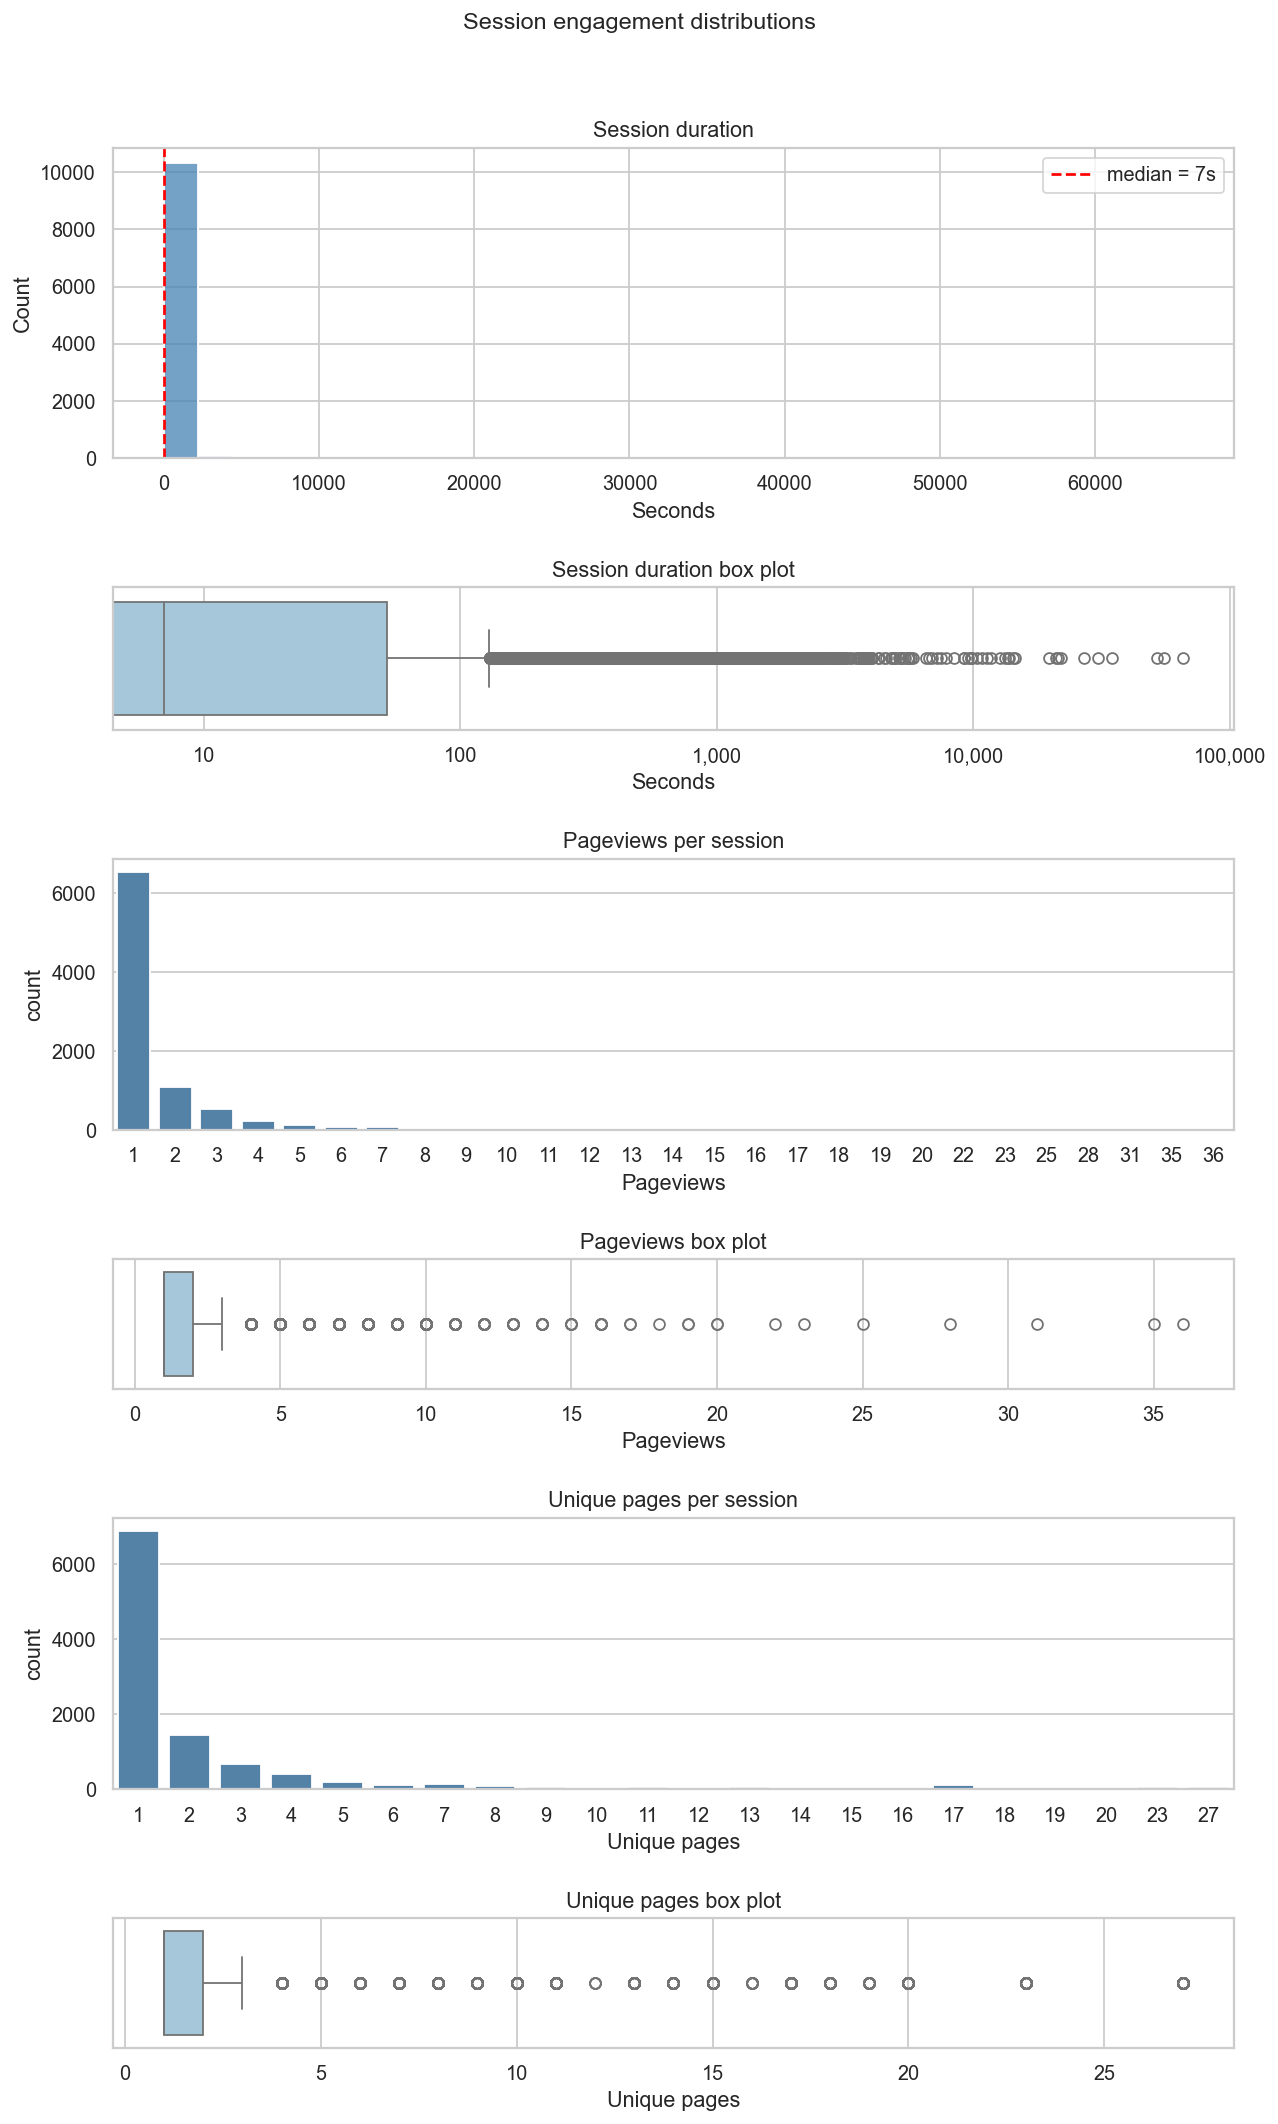

Duration percentiles


count    10462.000000
mean       195.518352
std       1354.916783
min          0.000000
25%          0.000000
50%          7.000000
75%         52.000000
max      65654.000000
Name: duration_seconds, dtype: float64

In [8]:
pageview_sessions_for_chart = web_sessions.loc[web_sessions["pageview_count"] > 0].copy()
duration_sessions_for_boxplot = web_sessions["duration_seconds"].dropna()

fig, axes = plt.subplots(6, 1, figsize=(10, 16), height_ratios=[2.4, 1.1, 2.1, 1.0, 2.1, 1.0])

sns.histplot(web_sessions["duration_seconds"], bins=30, ax=axes[0], color="steelblue")
axes[0].axvline(
    web_sessions["duration_seconds"].median(),
    color="red",
    ls="--",
    label=f"median = {web_sessions['duration_seconds'].median():.0f}s",
)
axes[0].set_title("Session duration")
axes[0].set_xlabel("Seconds")
axes[0].legend()

sns.boxplot(x=duration_sessions_for_boxplot, ax=axes[1], color="#9ecae1", showfliers=True)
axes[1].set_title("Session duration box plot")
axes[1].set_xlabel("Seconds")
axes[1].set_xscale("log")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}" if x >= 1 else ""))

sns.countplot(x="pageview_count", data=pageview_sessions_for_chart, ax=axes[2], color="steelblue")
axes[2].set_title("Pageviews per session")
axes[2].set_xlabel("Pageviews")

sns.boxplot(x=pageview_sessions_for_chart["pageview_count"], ax=axes[3], color="#9ecae1", showfliers=True)
axes[3].set_title("Pageviews box plot")
axes[3].set_xlabel("Pageviews")

sns.countplot(x="unique_urls_visited", data=web_sessions, ax=axes[4], color="steelblue")
axes[4].set_title("Unique pages per session")
axes[4].set_xlabel("Unique pages")

sns.boxplot(x=web_sessions["unique_urls_visited"], ax=axes[5], color="#9ecae1", showfliers=True)
axes[5].set_title("Unique pages box plot")
axes[5].set_xlabel("Unique pages")

fig.suptitle("Session engagement distributions", y=1.02, fontsize=13)
fig.tight_layout(h_pad=1.8)
fig.savefig(FIG_DIR / "04_session_engagement.png", dpi=150, bbox_inches="tight")
plt.show()
print("Duration percentiles")
display(web_sessions["duration_seconds"].describe())


### What this shows

- Session length, pageviews per session, and unique pages per session are all concentrated at low values.
- A smaller number of longer or deeper sessions pull the average upward.

### What this means for the findings

- Typical engagement is quite light, but a minority of visitors explore the site much more seriously.
- This supports the view that the website serves both quick information seekers and a smaller set of highly engaged visitors.


## 6. Landing pages, exits, and bounce rate by landing page


In [ ]:
# ── Top landing pages and top exit pages (equal-sized panels) ────────────────
land = web_sessions["landing_pathname"].map(pretty_page).value_counts().head(10).reset_index()
land.columns = ["Page", "Sessions"]
display(land)

exit_pages = web_sessions["exit_pathname"].map(pretty_page).value_counts().head(10).reset_index()
exit_pages.columns = ["Page", "Sessions"]
display(exit_pages)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=land, x="Sessions", y="Page", hue="Page", legend=False, ax=ax1, palette="Blues_d")
ax1.set_title("Top landing pages")
ax1.set_xlabel("Sessions")
ax1.set_ylabel("")
tidy_axes(ax1, orient="h")

sns.barplot(data=exit_pages, x="Sessions", y="Page", hue="Page", legend=False, ax=ax2, palette="Reds_d")
ax2.set_title("Top exit pages")
ax2.set_xlabel("Sessions")
ax2.set_ylabel("")
tidy_axes(ax2, orient="h")

fig.tight_layout()
fig.savefig(FIG_DIR / "05_landing_exit.png", dpi=150, bbox_inches="tight")
plt.show()


### What this shows

- Some pages are much more common as landing pages than others.
- Bounce rate differs across landing pages, which suggests some entry pages are better than others at moving people deeper into the site.

### What this means for the findings

- Entry-page quality matters, not just overall traffic volume.
- Pages with high traffic but high bounce may need clearer messaging or stronger next steps.


## 7. Page interest by vertical

`$pageview` is the standard page-load event, so the charts below focus on explicit page visits rather than all event types mixed together.

The dissertation plan later collapses pages into four business verticals. This notebook keeps a five-group descriptive view because `Content / Blog` pages behave differently from product pages, and `Regulatory & Brokers` is still analytically distinct in the website navigation and traffic mix.


In [10]:
VERTICAL_MAP = {
    "/": "Homepage",
    "/get-started": "Sign-up / Get Started",
    "/complex-claims": "Insurance",
    "/claim-risk": "Insurance",
    "/mna-dd": "Insurance",
    "/risk-insights": "Insurance",
    "/loss-fund-reconciliation": "Insurance",
    "/fund-diligence": "Investment",
    "/portfolio-monitoring": "Investment",
    "/company-diligence": "Investment",
    "/mortgage-validation": "Regulatory & Brokers",
    "/kyc-aml": "Regulatory & Brokers",
    "/lp-reporting": "Regulatory & Brokers",
    "/platform": "Generic Platform",
    "/about-us": "Generic Platform",
    "/api": "Generic Platform",
    "/pricing": "Generic Platform",
    "/pricing-platform": "Generic Platform",
    "/pricing-api": "Generic Platform",
    "/pde": "Generic Platform",
    "/software-3.0": "Generic Platform",
    "/privacy-policy": "Generic Platform",
    "/terms-and-conditions": "Generic Platform",
    "/introducing-navi": "Generic Platform",
    "/doc-processing-pipelines": "Generic Platform",
    "/core-loop": "Generic Platform",
    "/labs": "Content / Blog",
    "/solutions": "Content / Blog",
    "/ux-design-for-agent-workflows": "Content / Blog",
    "/slush": "Content / Blog",
}

web_events["vertical"] = web_events["pathname"].map(VERTICAL_MAP).fillna("Other")
pageviews = web_events.loc[web_events["event"] == "$pageview"].copy()

vertical_stats = (
    pageviews.groupby("vertical")
    .agg(pageviews=("event", "count"), unique_visitors=("distinct_id", "nunique"))
    .sort_values("pageviews", ascending=False)
    .reset_index()
)
vertical_stats["% of pageviews"] = (vertical_stats["pageviews"] / vertical_stats["pageviews"].sum() * 100).round(1)
display(vertical_stats)

pricing_pv = int((pageviews["pathname"] == "/pricing").sum())
display(
    Markdown(
        f"**⚠️ Note:** `/pricing` received **{pricing_pv:,} pageviews** and is the **3rd most visited URL** on the site, but the page currently returns a 404 on the live site. This is a significant UX and conversion issue worth flagging."
    )
)


,vertical,pageviews,unique_visitors,% of pageviews
0,Homepage,6655,4728,45.8
1,Generic Platform,4167,2396,28.7
2,Sign-up / Get Started,2026,1447,14.0
3,Content / Blog,1088,725,7.5
4,Insurance,244,145,1.7
5,Investment,173,108,1.2
6,Regulatory & Brokers,111,75,0.8
7,Other,59,57,0.4


'**⚠️ Note:** `/pricing` received **649 pageviews** and is the **3rd most visited URL** on the site, but the page currently returns a 404 on the live site. This is a significant UX and conversion issue worth flagging.'

In [ ]:
page_breakdown = (
    pageviews.groupby("pathname")
    .agg(pageviews=("event", "count"), unique_visitors=("distinct_id", "nunique"))
    .sort_values("pageviews", ascending=False)
    .head(20)
    .reset_index()
)
page_breakdown["Page"] = page_breakdown["pathname"].map(pretty_page)
page_breakdown["vertical"] = page_breakdown["pathname"].map(VERTICAL_MAP).fillna("Other")
display(page_breakdown[["Page", "pageviews", "unique_visitors", "vertical"]])

# Colour still encodes the use-case vertical (the caption relies on it), but the
# palette is pinned to the muted house colours for consistency with the other figures.
palette = {
    "Homepage": STEEL,
    "Sign-up / Get Started": MUTED[8],   # muted yellow
    "Generic Platform": MUTED[2],        # muted green
    "Insurance": MUTED[3],               # muted red
    "Investment": MUTED[4],              # muted purple
    "Regulatory & Brokers": MUTED[9],    # muted cyan
    "Content / Blog": MUTED[7],          # muted grey
    "Other": "#BBBBBB",
}

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=page_breakdown,
    x="pageviews",
    y="Page",
    hue="vertical",
    dodge=False,
    palette=palette,
    ax=ax,
)
ax.set_title("Top 20 pageviews by pathname")
ax.set_xlabel("Pageviews")
ax.set_ylabel("")
tidy_axes(ax, orient="h")
ax.legend(title="Vertical", bbox_to_anchor=(1.02, 1), loc="upper left", alignment="left",
          frameon=True, edgecolor="0.6", facecolor="white", framealpha=1)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_pageviews_by_page.png", dpi=150, bbox_inches="tight")
plt.show()


### What this shows

- Attention is concentrated in a small number of pages, especially the Home Page and the Get Started Page.
- The page ranking also shows which business areas appear to attract the most interest.

### What this means for the findings

- A small group of pages acts as the main attention hub for the website.
- This helps identify which pages are most important for explaining user interest and where conversion-related attention is strongest.


## 8. Event types & interaction friction

The tables below separate broad event counts from page-level friction signals. For the descriptive goal of this notebook, the main question is simply where dead clicks and rageclicks concentrate.


,Event type,Count,Description
0,$pageview,14523,Page loaded
1,$autocapture,12162,Auto-tracked click or field interaction
2,$web_vitals,10596,NaN
3,$pageleave,6874,Browser left a page
4,$dead_click,2408,Click with no visible result
5,$rageclick,142,Repeated rapid clicking in one area


,Interaction type,Count
0,click,8082
1,change,4059
2,submit,21


Dead clicks by page


,Page,dead_click_count
0,Home Page,334
1,API Page,273
2,Platform Page,271
3,Doc Processing Pipelines Page,163
4,PDE Page,155
5,Pricing Page,154
6,About Us Page,145
7,UX Design for Agent Workflows Page,136
8,Introducing Navi Page,111
9,Get Started Page,103


Rageclicks by page


,Page,rageclick_count
0,Get Started Page,55
1,Home Page,30
2,About Us Page,29
3,API Page,8
4,Platform Pricing Page,5
5,Labs Page,4
6,Platform Page,4
7,Pricing Page,3
8,Complex Claims Page,2
9,Solutions Page,2


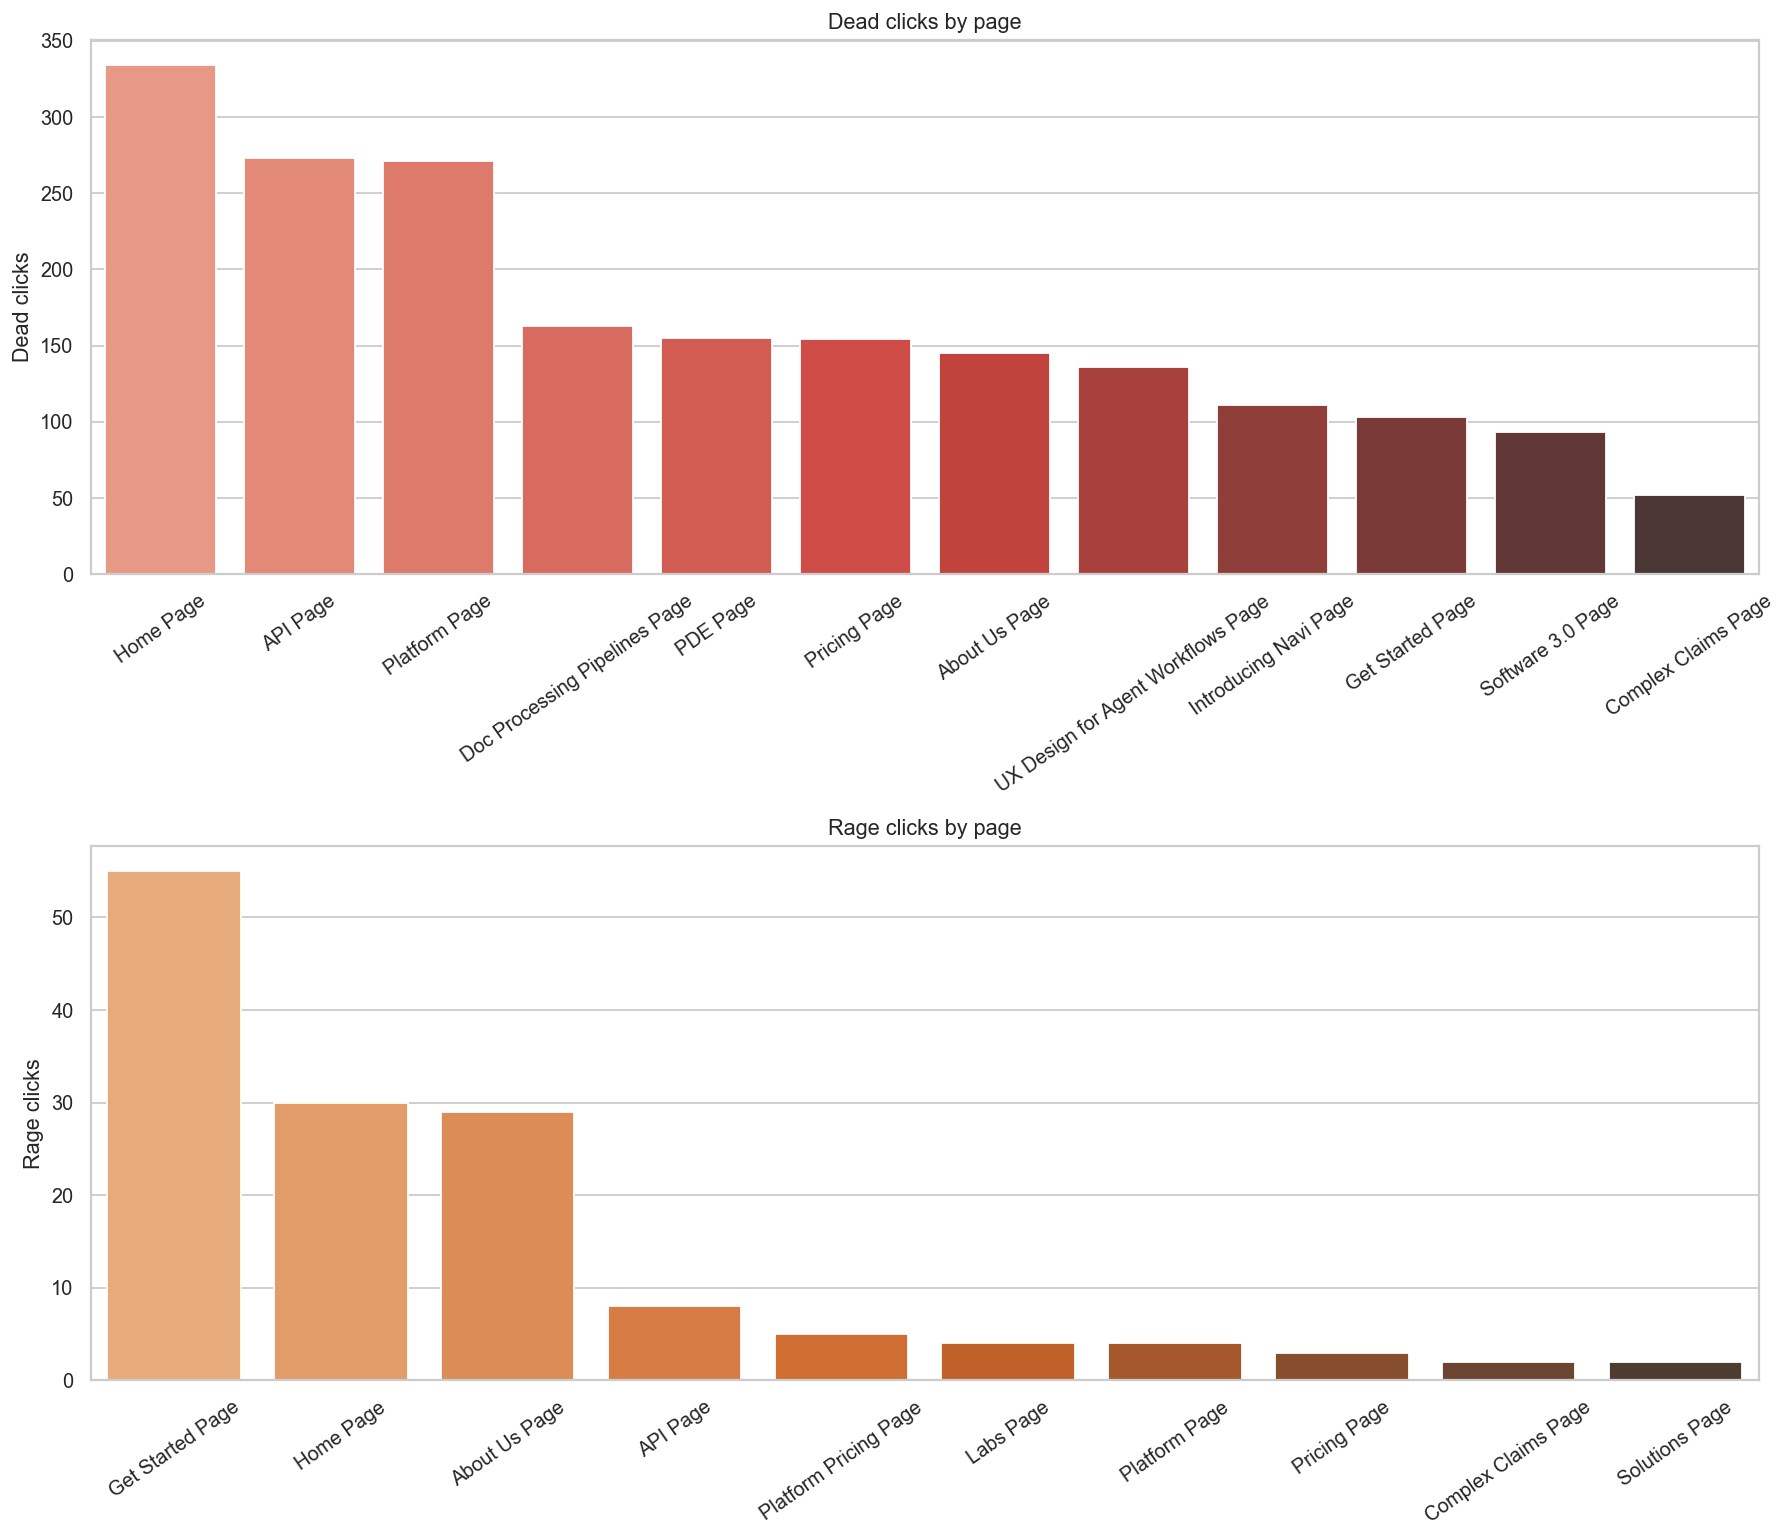

In [12]:
event_counts = web_events["event"].value_counts().reset_index()
event_counts.columns = ["Event type", "Count"]
event_counts["Description"] = event_counts["Event type"].map(
    {
        "$autocapture": "Auto-tracked click or field interaction",
        "$pageview": "Page loaded",
        "$pageleave": "Browser left a page",
        "$dead_click": "Click with no visible result",
        "$rageclick": "Repeated rapid clicking in one area",
    }
)
display(event_counts)

autocapture_types = (
    web_events.loc[web_events["event"] == "$autocapture", "ac_event_type"]
    .fillna("Unknown")
    .value_counts()
    .reset_index()
)
autocapture_types.columns = ["Interaction type", "Count"]
display(autocapture_types)

dead_clicks_by_page = (
    web_events.loc[web_events["event"] == "$dead_click"]
    .groupby("pathname")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="dead_click_count")
)
rageclicks_by_page = (
    web_events.loc[web_events["event"] == "$rageclick"]
    .groupby("pathname")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="rageclick_count")
)
dead_clicks_by_page["Page"] = dead_clicks_by_page["pathname"].map(pretty_page)
rageclicks_by_page["Page"] = rageclicks_by_page["pathname"].map(pretty_page)

print("Dead clicks by page")
display(dead_clicks_by_page[["Page", "dead_click_count"]])
print("Rageclicks by page")
display(rageclicks_by_page[["Page", "rageclick_count"]])

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.barplot(
    data=dead_clicks_by_page.head(12),
    x="Page",
    y="dead_click_count",
    hue="Page",
    legend=False,
    ax=axes[0],
    palette="Reds_d",
)
axes[0].set_title("Dead clicks by page")
axes[0].set_xlabel("")
axes[0].set_ylabel("Dead clicks")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(
    data=rageclicks_by_page.head(12),
    x="Page",
    y="rageclick_count",
    hue="Page",
    legend=False,
    ax=axes[1],
    palette="Oranges_d",
)
axes[1].set_title("Rage clicks by page")
axes[1].set_xlabel("")
axes[1].set_ylabel("Rage clicks")
axes[1].tick_params(axis="x", rotation=35)

fig.tight_layout()
fig.savefig(FIG_DIR / "08_friction_by_page.png", dpi=150, bbox_inches="tight")
plt.show()


### What this shows

- Most tracked activity comes from pageviews and autocaptured interactions, while dead clicks and rage clicks are much less common.
- The page-level friction tables show where these problematic interactions are concentrated.

### What this means for the findings

- The website is mainly being used in a normal browsing pattern, but some pages may still create confusion or frustration.
- These friction signals help identify where the interface may need improvement.


## 9. Page-to-page navigation Sankey

This Sankey diagram is a descriptive view of how pageview sequences unfold within sessions. It is built from ordered `$pageview` events, removes consecutive duplicate pageviews within the same session, and then shows the most common pages at steps 1 to 4 in the browsing path. Less common pages at each step are grouped into `Other` so the chart remains readable.


In [13]:
pageview_paths = web_events.loc[
    web_events["event"] == "$pageview",
    ["session_id", "distinct_id", "event_timestamp", "pathname"],
].copy()
pageview_paths = pageview_paths.sort_values(["session_id", "event_timestamp"])
pageview_paths["prev_pathname"] = pageview_paths.groupby("session_id")["pathname"].shift()
pageview_paths = pageview_paths.loc[
    pageview_paths["pathname"].notna()
    & pageview_paths["session_id"].notna()
    & (pageview_paths["pathname"] != pageview_paths["prev_pathname"])
].copy()
pageview_paths["step"] = pageview_paths.groupby("session_id").cumcount() + 1

max_step = 4
top_n_per_step = 7
sankey_paths = pageview_paths.loc[pageview_paths["step"] <= max_step].copy()

top_pages_by_step = {}
for step in range(1, max_step + 1):
    top_pages_by_step[step] = set(
        sankey_paths.loc[sankey_paths["step"] == step, "pathname"]
        .value_counts()
        .head(top_n_per_step)
        .index
    )

def bucket_page(pathname, step):
    if pathname in top_pages_by_step.get(step, set()):
        return pathname
    return "Other"

def sankey_page_label(pathname):
    if pathname == "Other":
        return "Other"
    return pretty_page(pathname)

sankey_paths["page_bucket"] = sankey_paths.apply(
    lambda row: bucket_page(row["pathname"], row["step"]), axis=1
)

session_steps = (
    sankey_paths.pivot_table(index="session_id", columns="step", values="page_bucket", aggfunc="first")
    .reset_index()
)
session_users = sankey_paths.groupby("session_id", as_index=False)["distinct_id"].first()
session_steps = session_steps.merge(session_users, on="session_id", how="left")
session_steps_display = session_steps.copy()
for step in range(1, max_step + 1):
    if step in session_steps_display.columns:
        session_steps_display[step] = session_steps_display[step].map(sankey_page_label)
display(session_steps_display.drop(columns=["distinct_id"]).head(10))

links = []
for step in range(1, max_step):
    current_col = step
    next_col = step + 1
    valid = session_steps.dropna(subset=[current_col, next_col]).copy()
    if len(valid) == 0:
        continue
    step_links = (
        valid.groupby([current_col, next_col], dropna=False)
        .agg(
            sessions=("session_id", "nunique"),
            users=("distinct_id", "nunique"),
        )
        .reset_index()
    )
    source_users = valid.groupby(current_col)["distinct_id"].nunique()
    source_sessions = valid.groupby(current_col)["session_id"].nunique()
    step_links["source_page"] = step_links[current_col]
    step_links["target_page"] = step_links[next_col]
    step_links["source_display"] = step_links["source_page"].map(sankey_page_label)
    step_links["target_display"] = step_links["target_page"].map(sankey_page_label)
    step_links["source_label"] = step_links["source_display"].map(lambda x: f"Step {step}: {x}")
    step_links["target_label"] = step_links["target_display"].map(lambda x: f"Step {step + 1}: {x}")
    step_links["step_pair"] = f"{step} to {step + 1}"
    step_links["source_total_users"] = step_links["source_page"].map(source_users)
    step_links["source_total_sessions"] = step_links["source_page"].map(source_sessions)
    links.append(
        step_links[
            [
                "step_pair",
                "source_page",
                "target_page",
                "source_display",
                "target_display",
                "source_label",
                "target_label",
                "users",
                "sessions",
                "source_total_users",
                "source_total_sessions",
            ]
        ]
    )

sankey_links = pd.concat(links, ignore_index=True)
sankey_links["pct_of_source_users"] = (
    sankey_links["users"] / sankey_links["source_total_users"] * 100
).round(1)
sankey_links["pct_of_source_sessions"] = (
    sankey_links["sessions"] / sankey_links["source_total_sessions"] * 100
).round(1)
total_sankey_sessions = sankey_links["sessions"].sum()
sankey_links["pct_of_all_sankey_flows"] = (
    sankey_links["sessions"] / total_sankey_sessions * 100
).round(1)
sankey_links = sankey_links.sort_values("sessions", ascending=False).reset_index(drop=True)
display(
    sankey_links[
        [
            "step_pair",
            "source_display",
            "target_display",
            "users",
            "sessions",
            "pct_of_source_users",
            "pct_of_source_sessions",
            "pct_of_all_sankey_flows",
        ]
    ].head(25)
)

node_labels = pd.Index(sankey_links["source_label"].tolist() + sankey_links["target_label"].tolist()).unique().tolist()
node_index = {label: i for i, label in enumerate(node_labels)}

link_customdata = sankey_links[
    [
        "source_display",
        "target_display",
        "step_pair",
        "users",
        "pct_of_source_users",
        "pct_of_source_sessions",
        "pct_of_all_sankey_flows",
        "source_total_users",
        "source_total_sessions",
    ]
].to_numpy()

sankey_fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=20,
                thickness=18,
                line=dict(color="rgba(40, 40, 40, 0.45)", width=0.6),
                label=node_labels,
                hovertemplate="%{label}<extra></extra>",
            ),
            link=dict(
                source=sankey_links["source_label"].map(node_index),
                target=sankey_links["target_label"].map(node_index),
                value=sankey_links["sessions"],
                customdata=link_customdata,
                hovertemplate=(
                    "%{customdata[2]}<br>"
                    "%{customdata[0]} to %{customdata[1]}<br>"
                    "Users: %{customdata[3]}<br>"
                    "Sessions: %{value}<br>"
                    "Share of users moving on from %{customdata[0]}: %{customdata[4]}%<br>"
                    "Share of sessions moving on from %{customdata[0]}: %{customdata[5]}%<br>"
                    "Share of all Sankey flows: %{customdata[6]}%<br>"
                    "Total users from %{customdata[0]}: %{customdata[7]}<br>"
                    "Total sessions from %{customdata[0]}: %{customdata[8]}"
                    "<extra></extra>"
                ),
            ),
        )
    ]
)
sankey_fig.update_layout(
    title=dict(text="Website page navigation Sankey", x=0.5, xanchor="center"),
    font=dict(size=12),
    height=700,
    width=1200,
)
sankey_fig.show()
sankey_fig.write_html(FIG_DIR / "08_page_navigation_sankey.html")
try:
    sankey_fig.write_image(FIG_DIR / "08_page_navigation_sankey.png", scale=2)
except Exception as _e:
    print(f"(png export unavailable: {_e})")


,session_id,1,2,3,4
0,019c9920-0c59-7f9f-9072-78327d7f2f15,Home Page,Pricing Page,Home Page,Get Started Page
1,019c9929-915e-7943-b99f-ff5b03b61406,Home Page,Unknown,Unknown,Unknown
2,019c9953-5203-73f1-bd1d-a0091fa2b236,Home Page,Unknown,Unknown,Unknown
3,019c9955-af77-70ed-988d-eeb20973b209,Home Page,Pricing Page,Get Started Page,Pricing Page
4,019c9957-5ee0-72d3-8527-598b83d84682,Get Started Page,Unknown,Unknown,Unknown
5,019c995c-2ca4-7098-9fb3-23c81c8273b2,Home Page,Unknown,Unknown,Unknown
6,019c995c-4ba7-72fa-b684-e88b167c27eb,Get Started Page,Home Page,Unknown,Unknown
7,019c9961-31e1-73aa-8dd4-307f9b48a82c,Get Started Page,Unknown,Unknown,Unknown
8,019c9961-3965-7a90-aa30-ebd52df7b90d,Get Started Page,Unknown,Unknown,Unknown
9,019c9961-3b64-7d80-9328-31c2aae32db2,Get Started Page,Unknown,Unknown,Unknown


,step_pair,source_display,target_display,users,sessions,pct_of_source_users,pct_of_source_sessions,pct_of_all_sankey_flows
0,1 to 2,Home Page,Pricing Page,282,295,25.0,21.5,8.2
1,1 to 2,Home Page,Other,216,269,19.1,19.6,7.5
2,1 to 2,Home Page,Platform Page,234,263,20.7,19.2,7.3
3,1 to 2,Home Page,Get Started Page,227,255,20.1,18.6,7.1
4,1 to 2,Home Page,About Us Page,150,156,13.3,11.4,4.3
5,1 to 2,Get Started Page,Home Page,118,118,39.5,39.1,3.3
6,1 to 2,API Page,Platform Pricing Page,100,102,51.5,51.5,2.8
7,1 to 2,Home Page,Solutions Page,96,101,8.5,7.4,2.8
8,1 to 2,Get Started Page,Platform Page,94,94,31.4,31.1,2.6
9,2 to 3,Other,Other,77,93,47.5,45.8,2.6


### What this shows

- The Sankey diagram shows the most common next-step paths through the site, not total page popularity.
- It helps show where visitors go immediately after key pages such as the Home Page.

### What this means for the findings

- This gives a clearer picture of navigation behaviour than pageview totals alone.
- A page can be highly visited overall while still not being the most common immediate next step from the Home Page.


> Note: the Sankey diagram above measures session paths rather than total pageviews.


## 10. Engagement by channel


In [14]:
channel_engagement = (
    web_sessions.groupby("channel_type")
    .agg(
        sessions=("session_id", "count"),
        unique_visitors=("distinct_id", "nunique"),
        bounce_rate=("is_bounce", "mean"),
        median_duration_s=("duration_seconds", "median"),
        mean_duration_s=("duration_seconds", "mean"),
        mean_pageviews=("pageview_count", "mean"),
        mean_unique_pages=("unique_urls_visited", "mean"),
    )
    .sort_values("sessions", ascending=False)
    .reset_index()
)
channel_engagement["bounce_rate"] = (channel_engagement["bounce_rate"] * 100).round(1)
channel_engagement["mean_pageviews"] = channel_engagement["mean_pageviews"].round(2)
channel_engagement["mean_unique_pages"] = channel_engagement["mean_unique_pages"].round(2)
channel_engagement["mean_duration_s"] = channel_engagement["mean_duration_s"].round(1)
channel_label_map = {
    "Direct": "Direct",
    "Organic Search": "Organic Search",
    "Referral": "3rd Party Website",
    "Organic Social": "Social Media Sites",
    "Email": "Email Account",
    "Organic Video": "Video Platform",
    "Paid Unknown": "Other (unable to classify)",
}
channel_engagement["channel_type"] = channel_engagement["channel_type"].map(channel_label_map).fillna(channel_engagement["channel_type"])
channel_engagement.columns = [
    "Channel",
    "Sessions",
    "Visitors",
    "Bounce %",
    "Median duration (s)",
    "Mean duration (s)",
    "Mean pageviews",
    "Mean unique pages",
]

channel_engagement_display = channel_engagement.copy()
channel_engagement_display["Sessions"] = channel_engagement_display["Sessions"].astype(int)
channel_engagement_display["Visitors"] = channel_engagement_display["Visitors"].astype(int)
channel_engagement_display["Bounce %"] = channel_engagement_display["Bounce %"].map(lambda x: f"{x:.1f}" if isinstance(x, (int, float)) else x)
channel_engagement_display["Median duration (s)"] = channel_engagement_display["Median duration (s)"].map(lambda x: f"{x:.0f}" if isinstance(x, (int, float)) else x)
channel_engagement_display["Mean duration (s)"] = channel_engagement_display["Mean duration (s)"].map(lambda x: f"{x:.1f}" if isinstance(x, (int, float)) else x)
channel_engagement_display["Mean pageviews"] = channel_engagement_display["Mean pageviews"].map(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x)
channel_engagement_display["Mean unique pages"] = channel_engagement_display["Mean unique pages"].map(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x)

styled_channel_engagement = (
    channel_engagement_display.style.hide(axis="index")
    .set_properties(**{"text-align": "center", "white-space": "normal"})
    .set_properties(subset=["Channel"], **{"text-align": "left", "min-width": "180px"})
    .set_table_styles(
        [
            {"selector": "table", "props": [("width", "100%"), ("border-collapse", "collapse"), ("table-layout", "fixed")]},
            {"selector": "th", "props": [("background-color", "#23436b"), ("color", "white"), ("font-weight", "bold"), ("padding", "10px 8px"), ("border", "1px solid white"), ("white-space", "normal")]},
            {"selector": "td", "props": [("padding", "8px"), ("border", "1px solid white"), ("color", "#1f2937")]},
            {"selector": "tbody tr:nth-child(odd)", "props": [("background-color", "#f8fafc")]},
            {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#e8eef7")]},
        ]
    )
)
display(styled_channel_engagement)


Channel,Sessions,Visitors,Bounce %,Median duration (s),Mean duration (s),Mean pageviews,Mean unique pages
3rd Party Website,8564,6637,10.8,6,167.4,1.31,2.39
Organic Search,1317,896,5.8,25,364.6,1.70,2.69
Social Media Sites,581,516,10.3,13,226.7,1.79,2.17


### What this shows

- Different traffic channels bring different levels of engagement, not just different numbers of sessions.
- Bounce rate, duration, and page depth can be compared side by side for each channel.

### What this means for the findings

- The most visible channel is not always the most valuable one in terms of engagement quality.
- This helps separate traffic volume from traffic quality.


## 11. `/get-started` — the sign-up page

`/get-started` is the website's sign-up page, so it is the closest on-site page to a conversion step in this export. The `change` events shown below are a **form-engagement proxy**: they indicate that a visitor interacted with a field on the form, not that they completed registration.


,Metric,Value
0,Visitors who reached the Get Started Page,"1,456"
1,Share of all site visitors who reached the Get...,18.4%
2,Total events on the Get Started Page,"6,918"
3,Visitors who interacted with the form (change ...,527
4,Share of all site visitors who interacted with...,6.6%


,Stage,Visitors,Share of previous stage,Share of home page stage
0,Visited Home Page,5075,100.0%,100.0
1,Then reached Get Started Page,462,9.1%,9.1
2,Then triggered form change event,185,40.0%,3.6


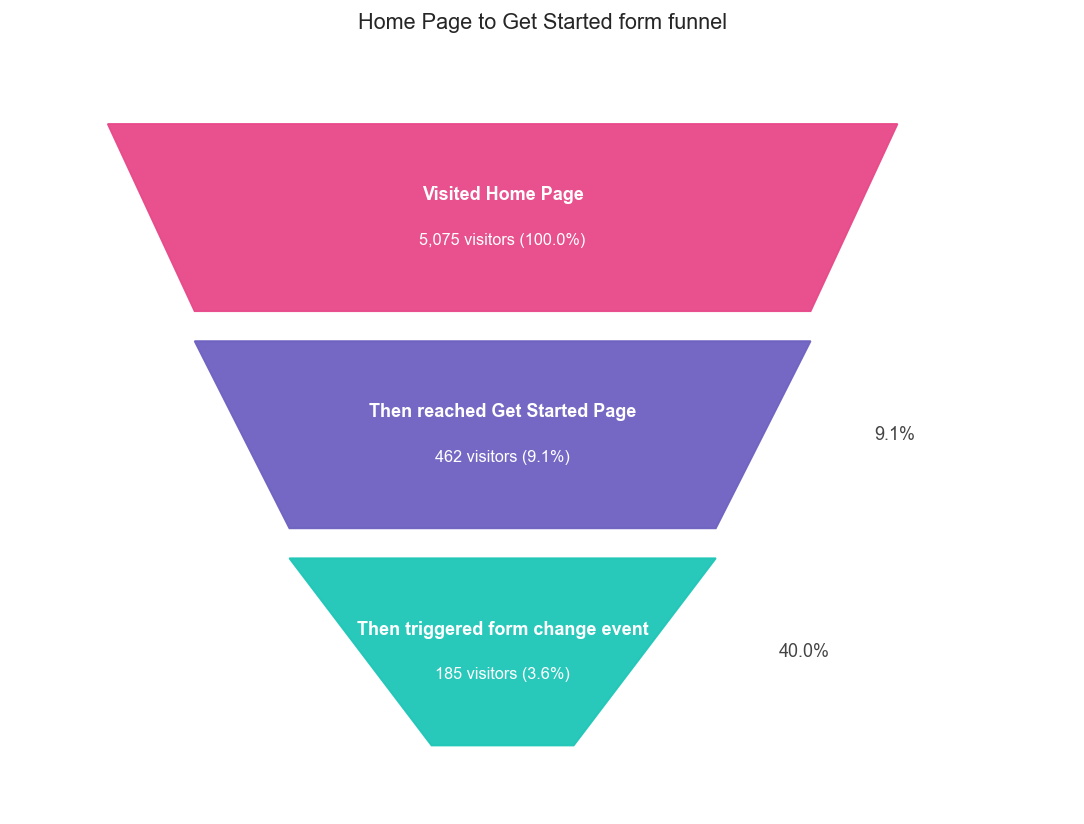

,Event,Count
0,$autocapture,2448
1,$pageview,2026
2,$web_vitals,1680
3,$pageleave,606
4,$dead_click,103
5,$rageclick,55


,Page,total_pageviews,exit_sessions,unique_exiting_users,share_of_all_visitors_pct,exit_users_per_100_pageviews
0,Home Page,6655.0,5505,4284,54.1,64.4
1,Get Started Page,2026.0,1218,1063,13.4,52.5
2,API Page,1255.0,1024,864,10.9,68.8
3,Platform Page,927.0,552,398,5.0,42.9
4,Solutions Page,512.0,335,312,3.9,60.9
5,Labs Page,533.0,318,284,3.6,53.3
6,API Pricing Page,243.0,287,280,3.5,115.2
7,Pricing Page,649.0,319,274,3.5,42.2
8,About Us Page,385.0,254,194,2.4,50.4
9,Platform Pricing Page,282.0,115,106,1.3,37.6


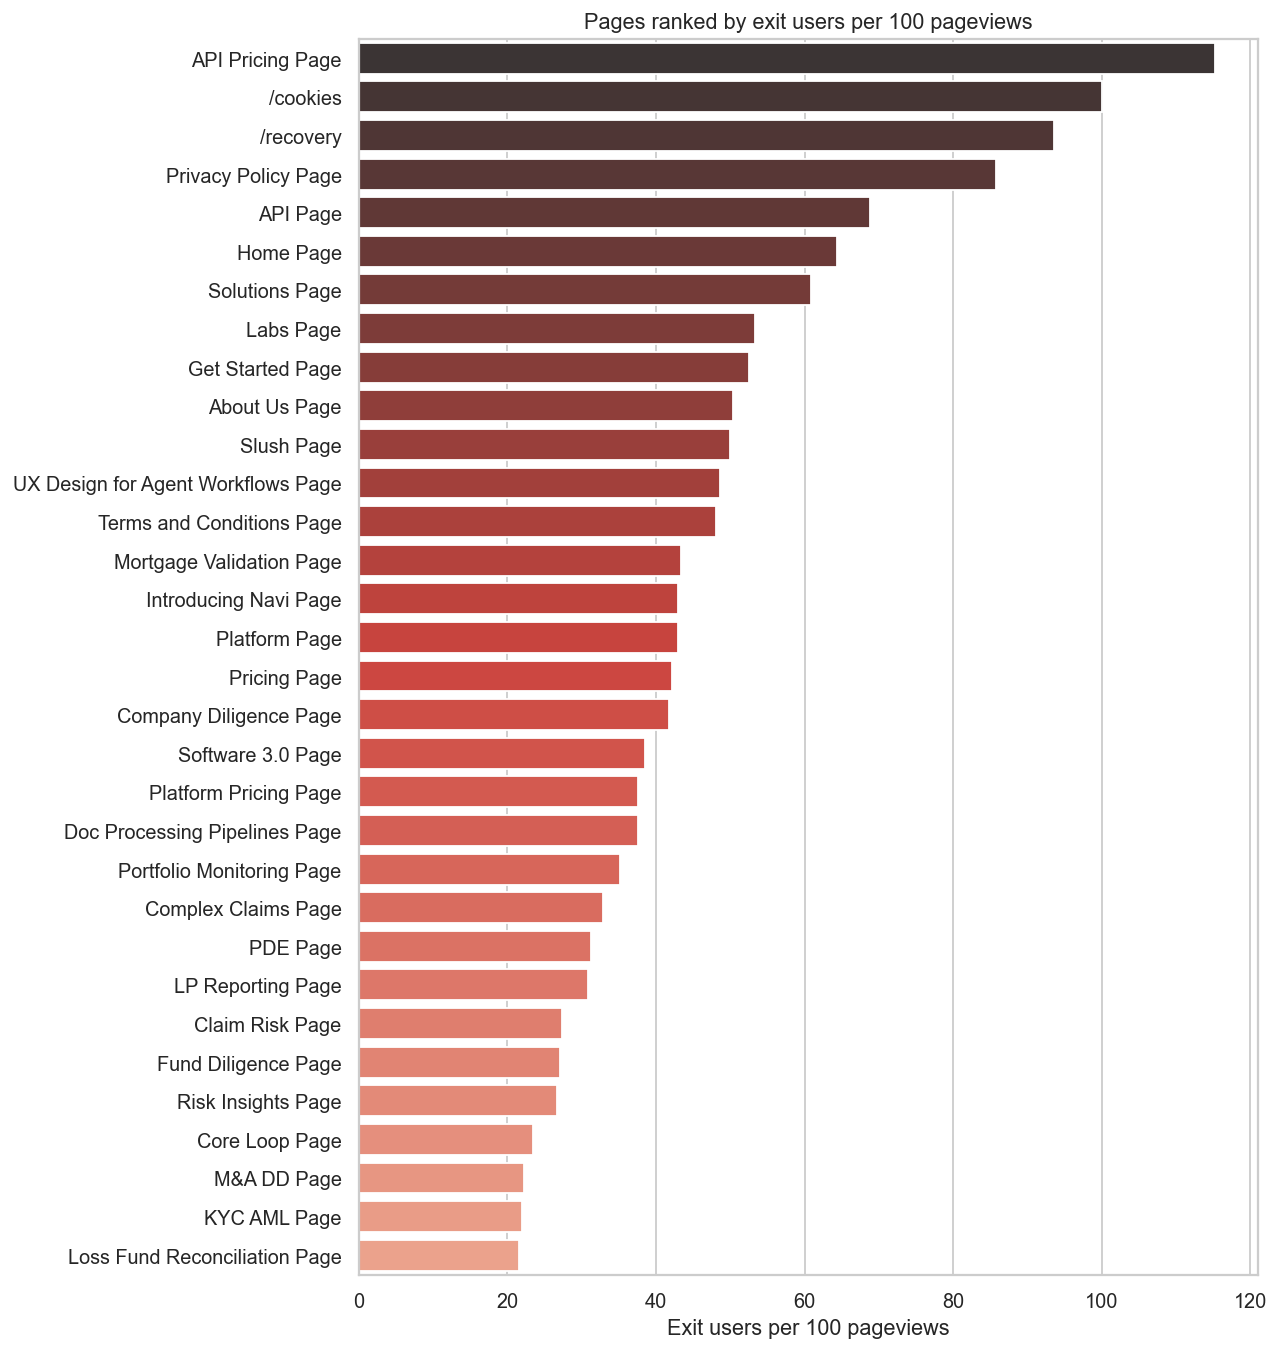

In [15]:
get_started_events = web_events.loc[web_events["pathname"] == "/get-started"].copy()
get_started_visitors = get_started_events["distinct_id"].nunique()

form_interactions = get_started_events.loc[
    (get_started_events["event"] == "$autocapture")
    & (get_started_events["ac_event_type"] == "change")
].copy()
form_visitors = form_interactions["distinct_id"].nunique()

get_started_summary = pd.DataFrame(
    {
        "Metric": [
            "Visitors who reached the Get Started Page",
            "Share of all site visitors who reached the Get Started Page",
            "Total events on the Get Started Page",
            "Visitors who interacted with the form (change events)",
            "Share of all site visitors who interacted with the form",
        ],
        "Value": [
            f"{get_started_visitors:,}",
            f"{get_started_visitors / total_visitors * 100:.1f}%",
            f"{len(get_started_events):,}",
            f"{form_visitors:,}",
            f"{form_visitors / total_visitors * 100:.1f}%",
        ],
    }
)
display(get_started_summary)

home_page_visitors = set(web_events.loc[web_events["pathname"] == "/", "distinct_id"].dropna())
get_started_visitor_ids = set(get_started_events["distinct_id"].dropna())
form_visitor_ids = set(form_interactions["distinct_id"].dropna())

funnel_counts = pd.DataFrame(
    {
        "Stage": [
            "Visited Home Page",
            "Then reached Get Started Page",
            "Then triggered form change event",
        ],
        "Visitors": [
            len(home_page_visitors),
            len(home_page_visitors & get_started_visitor_ids),
            len(home_page_visitors & get_started_visitor_ids & form_visitor_ids),
        ],
    }
)
funnel_counts["Share of previous stage"] = [
    "100.0%",
    f"{funnel_counts.loc[1, 'Visitors'] / funnel_counts.loc[0, 'Visitors'] * 100:.1f}%",
    f"{funnel_counts.loc[2, 'Visitors'] / funnel_counts.loc[1, 'Visitors'] * 100:.1f}%",
]
funnel_counts["Share of home page stage"] = (
    funnel_counts["Visitors"] / funnel_counts.loc[0, "Visitors"] * 100
).round(1)
display(funnel_counts)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
colors = ["#e84a8a", "#6f63c2", "#21c7b8"]
stage_height = 1.0
gap = 0.16
top_widths = [1.0, 0.78, 0.54]
bottom_widths = [0.78, 0.54, 0.18]
top_edges = []
bottom_edges = []
current_top = 0.0
for _ in funnel_counts.index:
    top_edges.append(current_top)
    bottom_edges.append(current_top - stage_height)
    current_top = current_top - stage_height - gap

for i, row in funnel_counts.iterrows():
    top_width = top_widths[i]
    bottom_width = bottom_widths[i]
    y_top = top_edges[i]
    y_bottom = bottom_edges[i]
    polygon_x = [
        -top_width / 2,
        top_width / 2,
        bottom_width / 2,
        -bottom_width / 2,
    ]
    polygon_y = [y_top, y_top, y_bottom, y_bottom]
    ax.fill(polygon_x, polygon_y, color=colors[i], alpha=0.97)
    y_mid = (y_top + y_bottom) / 2
    ax.text(0, y_mid + 0.12, row["Stage"], ha="center", va="center", color="white", fontsize=10, fontweight="bold")
    ax.text(0, y_mid - 0.12, f"{row['Visitors']:,} visitors ({row['Share of home page stage']:.1f}%)", ha="center", va="center", color="white", fontsize=9)
    if i > 0:
        ax.text(top_width / 2 + 0.08, y_mid, row["Share of previous stage"], ha="left", va="center", fontsize=10, color="#444444")

ax.set_title("Home Page to Get Started form funnel")
ax.set_xlim(-0.62, 0.72)
ax.set_ylim(bottom_edges[-1] - 0.35, 0.45)
ax.axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / "09_get_started_funnel.png", dpi=150, bbox_inches="tight")
plt.show()

get_started_event_counts = get_started_events["event"].value_counts().rename_axis("Event").reset_index(name="Count")
display(get_started_event_counts)

pageview_totals = (
    pageviews.groupby("pathname")
    .agg(total_pageviews=("event", "count"), pageview_visitors=("distinct_id", "nunique"))
    .reset_index()
)

exit_page_users = (
    web_sessions.loc[web_sessions["exit_pathname"].notna()]
    .groupby("exit_pathname")
    .agg(
        exit_sessions=("session_id", "count"),
        unique_exiting_users=("distinct_id", "nunique"),
    )
    .reset_index()
    .rename(columns={"exit_pathname": "pathname"})
)
exit_page_users = exit_page_users.merge(pageview_totals, on="pathname", how="left")
exit_page_users["Page"] = exit_page_users["pathname"].map(pretty_page)
exit_page_users["share_of_all_visitors_pct"] = (
    exit_page_users["unique_exiting_users"] / web_events["distinct_id"].nunique() * 100
).round(1)
exit_page_users["exit_users_per_100_pageviews"] = (
    exit_page_users["unique_exiting_users"] / exit_page_users["total_pageviews"] * 100
).round(1)
exit_page_users = exit_page_users.sort_values(
    ["unique_exiting_users", "exit_sessions"], ascending=[False, False]
).reset_index(drop=True)
display(
    exit_page_users[
        [
            "Page",
            "total_pageviews",
            "exit_sessions",
            "unique_exiting_users",
            "share_of_all_visitors_pct",
            "exit_users_per_100_pageviews",
        ]
    ]
)

exit_plot = exit_page_users.loc[exit_page_users["total_pageviews"].fillna(0) > 0].copy()
exit_plot = exit_plot.sort_values("exit_users_per_100_pageviews", ascending=True)
fig_height = max(7, len(exit_plot) * 0.33)
fig, ax = plt.subplots(figsize=(10, fig_height))
sns.barplot(
    data=exit_plot,
    x="exit_users_per_100_pageviews",
    y="Page",
    hue="Page",
    legend=False,
    ax=ax,
    palette="Reds_d",
)
ax.invert_yaxis()
ax.set_title("Pages ranked by exit users per 100 pageviews")
ax.set_xlabel("Exit users per 100 pageviews")
ax.set_ylabel("")
fig.tight_layout()
plt.show()








### Conversion proxy by first-touch acquisition source

The funnel above shows *that* most converters arrive primed; this asks *from where*. Each visitor is attributed to the source of their first session, and the form-engagement proxy is compared across sources with Wilson 95% intervals.

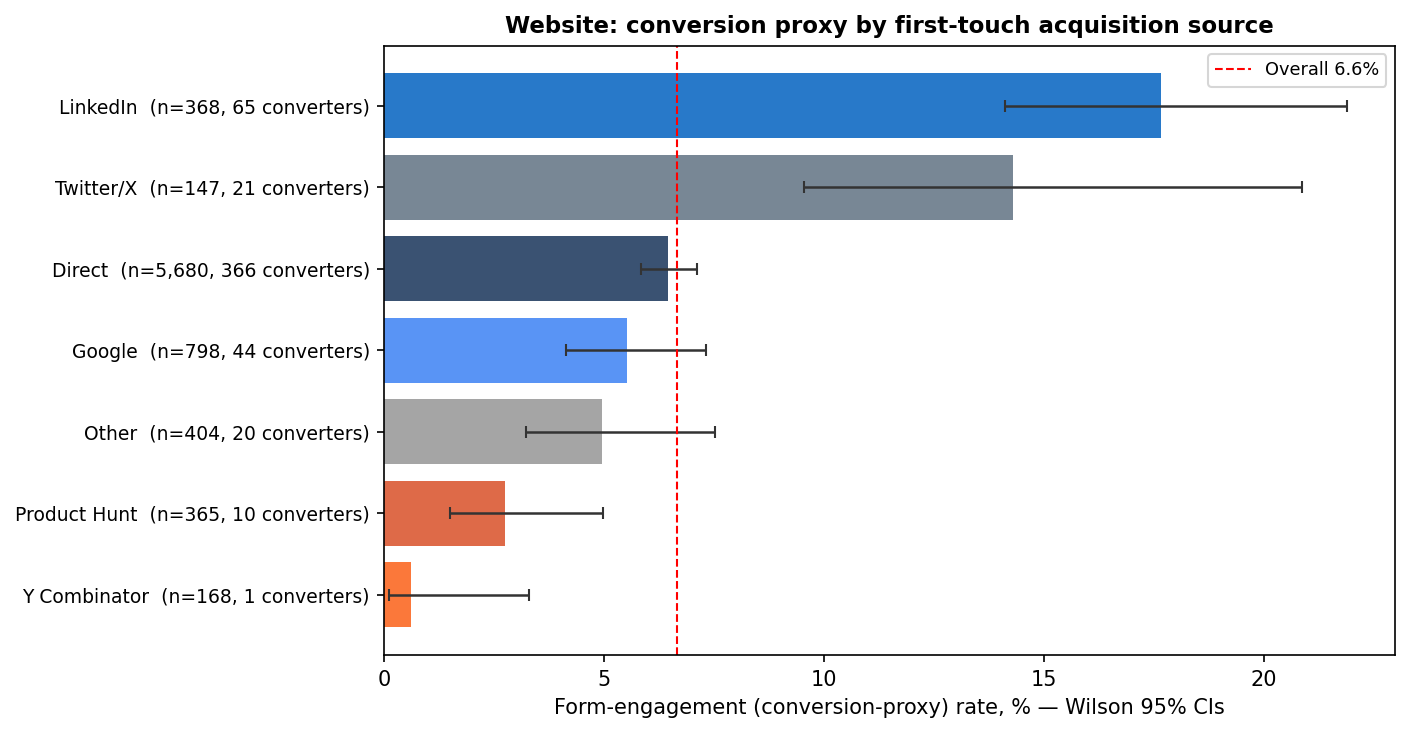

In [ ]:
if "source_group" not in web_sessions.columns:
    _SRC_ORDER = ["Direct", "Google", "LinkedIn", "Product Hunt", "Twitter/X", "Y Combinator", "Other"]
    _SRC_COLORS = {"Direct": "#1F3A5F", "Google": "#4285F4", "LinkedIn": "#0A66C2",
                   "Product Hunt": "#DA552F", "Twitter/X": "#657786", "Y Combinator": "#FB651E", "Other": "#999999"}
    
    def _source_group(domain):
        if pd.isna(domain) or str(domain).strip() in ("", "nan", "$direct", "Direct"):
            return "Direct"
        d = str(domain).lower().replace("www.", "")
        if "google" in d: return "Google"
        if "linkedin" in d or d.startswith("lnkd"): return "LinkedIn"
        if "producthunt" in d: return "Product Hunt"
        if d in ("t.co", "twitter.com", "x.com") or "twitter" in d: return "Twitter/X"
        if "ycombinator" in d: return "Y Combinator"
        return "Other"
    web_sessions["source_group"] = web_sessions["referring_domain"].map(_source_group)

def _wilson(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0, centre - half), min(1, centre + half))

_first = web_sessions.sort_values("session_start").drop_duplicates("distinct_id")[["distinct_id", "source_group"]]
_first["converted"] = _first["distinct_id"].isin(form_visitor_ids)
conv_by_source = (
    _first.groupby("source_group")
    .agg(visitors=("distinct_id", "nunique"), converters=("converted", "sum"))
)
conv_by_source["rate"] = conv_by_source["converters"] / conv_by_source["visitors"]
conv_by_source[["lo", "hi"]] = [
    _wilson(k, n) for k, n in zip(conv_by_source["converters"], conv_by_source["visitors"])
]
conv_by_source = conv_by_source.sort_values("rate")
display(conv_by_source.round(4))

fig, ax = plt.subplots(figsize=(9.5, 5))
_y = range(len(conv_by_source))
ax.barh(_y, conv_by_source["rate"] * 100, color="#4C72B0")
ax.errorbar(conv_by_source["rate"] * 100, _y,
            xerr=[(conv_by_source["rate"] - conv_by_source["lo"]) * 100,
                  (conv_by_source["hi"] - conv_by_source["rate"]) * 100],
            fmt="none", ecolor="#555", elinewidth=1.0, capsize=3)
_overall = _first["converted"].mean() * 100
ax.axvline(_overall, color="red", ls="--", lw=1, label=f"Overall average {_overall:.1f}%")
ax.set_yticks(list(_y))
ax.set_yticklabels([f"{s}  (n={int(v):,}, {int(c)} converters)"
                    for s, v, c in zip(conv_by_source.index, conv_by_source["visitors"], conv_by_source["converters"])], fontsize=9)
ax.set_xlabel("Proxy conversion rate (%) with Wilson 95% confidence intervals")
ax.set_title("Website: conversion proxy by acquisition source")
ax.legend(fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "12_conversion_by_source.png", dpi=150, bbox_inches="tight")
plt.show()


### What this shows

- The Get Started Page is one of the most important pages in the dataset and acts as the closest on-site conversion proxy.
- The table separates people who reached the page, total activity on the page, and people who interacted with the form.

### What this means for the findings

- This section gives the clearest descriptive view of conversion-related interest on the site.
- It helps distinguish between simple page exposure and more active form engagement.


In [16]:
top_channel = web_sessions["channel_type"].fillna("Unknown").value_counts().index[0]
top_channel_pct = web_sessions["channel_type"].fillna("Unknown").value_counts(normalize=True).iloc[0] * 100
top_referrers = ", ".join(web_sessions["referring_domain"].fillna("Unknown").value_counts().head(3).index.tolist())
top_countries = ", ".join(
    web_events.groupby("country")["distinct_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)

summary = pd.DataFrame(
    {
        "Metric": [
            "Unique visitors",
            "Sessions",
            "Bounce rate",
            "Median session duration",
            "Most common channel",
            "Top referring domains",
            "Top countries",
            "Reached Get Started Page",
            "Form engagement on Get Started Page",
        ],
        "Value": [
            total_visitors,
            len(web_sessions),
            f"{web_sessions['is_bounce'].mean() * 100:.1f}%",
            f"{web_sessions['duration_seconds'].median():.0f}s",
            f"{top_channel} ({top_channel_pct:.1f}%)",
            top_referrers,
            top_countries,
            f"{get_started_visitors} visitors ({get_started_visitors / total_visitors * 100:.1f}%)",
            f"{form_visitors} visitors ({form_visitors / total_visitors * 100:.1f}%)",
        ],
    }
)
display(summary)


,Metric,Value
0,Unique visitors,7925
1,Sessions,10462
2,Bounce rate,10.2%
3,Median session duration,7s
4,Most common channel,Referral (81.9%)
5,Top referring domains,"$direct, www.google.com, www.producthunt.com"
6,Top countries,"United States, India, United Kingdom, Germany"
7,Reached Get Started Page,1456 visitors (18.4%)
8,Form engagement on Get Started Page,527 visitors (6.6%)


## 12. Use-case interest and conversions

This table asks a simpler question before any clustering: among website visitors, who never looked at the specific industry use-case pages, and among those who did, which of the three use-case groups they spent the most time on.

The use-case groups here are restricted to the exact nine items shown in the website navigation:
- `Insurance`: Complex Claims Management, Portfolio M&A Due Diligence, Recovery Optimization
- `Asset Management`: Fund Diligence & KPI Validation, Company Data Room Diligence, Portfolio Performance Monitoring
- `Regulatory & Brokers`: Mortgage & Loan File Validation, LP Reporting & Data Validation, KYC Investigation Support

In path terms, that means the notebook uses `/complex-claims`, `/mna-dd`, `/loss-fund-reconciliation`, `/fund-diligence`, `/company-diligence`, `/portfolio-monitoring`, `/mortgage-validation`, `/lp-reporting`, and `/kyc-aml`.

Time spent is estimated from the gap between one pageview and the next pageview in the same session, capped at 30 minutes per page. `converted` is still the same website proxy: a `change` event on the Get Started form.


,dominant use-case interest,visitors,total_seconds_in_dominant_use_case,average_seconds_in_dominant_use_case,converted,median_seconds_in_dominant_use_case,conversion_rate
0,No specific use-case pages viewed,7737,0.000,0.000000,503,0.0000,6.5%
1,Insurance,58,13173.787,227.134259,5,36.5965,8.6%
2,Asset Management,75,14134.370,188.458267,9,16.9150,12.0%
3,Regulatory & Brokers,55,9983.621,181.520382,10,25.7800,18.2%


,Page,visitors,total_seconds,average_seconds,converted,median_seconds,conversion_rate
0,KYC Investigation Support,18,5290.510,293.917222,6,27.5335,33.333333
1,Fund Diligence & KPI Validation,24,1211.833,50.493042,6,10.4290,25.000000
2,Portfolio M&A Due Diligence,11,4230.384,384.580364,2,24.4260,18.181818
3,Portfolio Performance Monitoring,27,6851.929,253.775148,3,16.9150,11.111111
4,Recovery Optimization,18,1556.407,86.467056,2,22.6580,11.111111
5,LP Reporting & Data Validation,9,217.592,24.176889,1,13.7450,11.111111
6,Mortgage & Loan File Validation,36,3567.528,99.098000,3,19.5170,8.333333
7,Complex Claims Management,33,4955.206,150.157758,1,33.6280,3.030303
8,Company Data Room Diligence,35,7013.696,200.391314,1,13.4960,2.857143


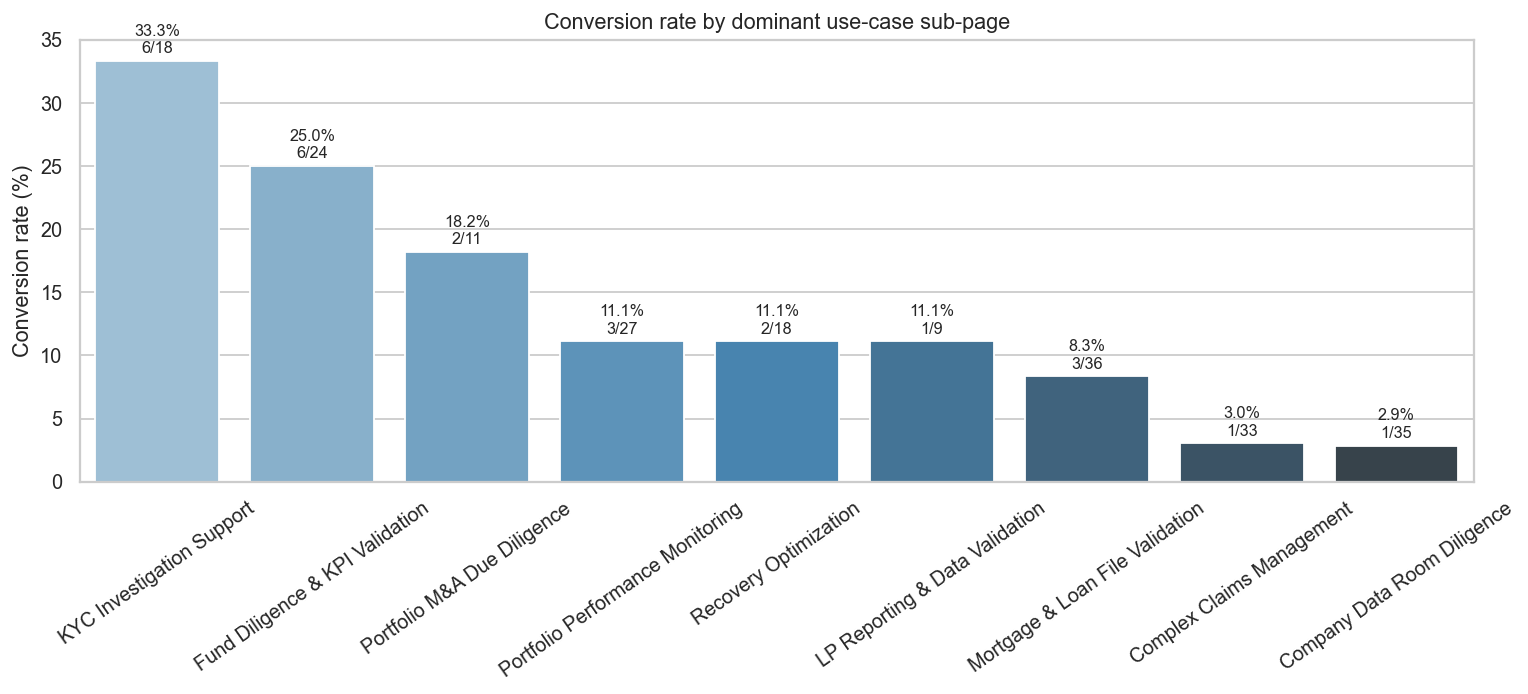

In [17]:
USE_CASE_MAP = {
    "/complex-claims": "Insurance",
    "/mna-dd": "Insurance",
    "/loss-fund-reconciliation": "Insurance",
    "/fund-diligence": "Asset Management",
    "/company-diligence": "Asset Management",
    "/portfolio-monitoring": "Asset Management",
    "/mortgage-validation": "Regulatory & Brokers",
    "/lp-reporting": "Regulatory & Brokers",
    "/kyc-aml": "Regulatory & Brokers",
}

page_time = pageviews[["session_id", "distinct_id", "event_timestamp", "pathname"]].copy()
page_time = page_time.sort_values(["session_id", "event_timestamp"])
page_time["next_pageview_time"] = page_time.groupby("session_id")["event_timestamp"].shift(-1)
session_end_map = web_sessions.set_index("session_id")["session_end"]
page_time["session_end"] = page_time["session_id"].map(session_end_map)
page_time["page_exit_time"] = page_time["next_pageview_time"].fillna(page_time["session_end"])
page_time["seconds_on_page"] = (
    page_time["page_exit_time"] - page_time["event_timestamp"]
).dt.total_seconds()
page_time["seconds_on_page"] = page_time["seconds_on_page"].clip(lower=0, upper=1800)
page_time = page_time.loc[page_time["seconds_on_page"].notna()].copy()
page_time["use_case_group"] = page_time["pathname"].map(USE_CASE_MAP)

use_case_time = (
    page_time.loc[page_time["use_case_group"].notna()]
    .groupby(["distinct_id", "use_case_group"], as_index=False)["seconds_on_page"]
    .sum()
)
use_case_pivot = use_case_time.pivot(
    index="distinct_id", columns="use_case_group", values="seconds_on_page"
).fillna(0)
for col in ["Insurance", "Asset Management", "Regulatory & Brokers"]:
    if col not in use_case_pivot.columns:
        use_case_pivot[col] = 0
use_case_pivot = use_case_pivot.reset_index()
use_case_pivot["total_use_case_seconds"] = (
    use_case_pivot["Insurance"]
    + use_case_pivot["Asset Management"]
    + use_case_pivot["Regulatory & Brokers"]
)


def assign_use_case_interest(row):
    if row["total_use_case_seconds"] <= 0:
        return "No specific use-case pages viewed"
    scores = {
        "Insurance": row["Insurance"],
        "Asset Management": row["Asset Management"],
        "Regulatory & Brokers": row["Regulatory & Brokers"],
    }
    return max(scores, key=scores.get)


use_case_pivot["dominant use-case interest"] = use_case_pivot.apply(assign_use_case_interest, axis=1)
use_case_pivot["seconds_in_dominant_use_case"] = use_case_pivot.apply(
    lambda row: 0
    if row["dominant use-case interest"] == "No specific use-case pages viewed"
    else row[row["dominant use-case interest"]],
    axis=1,
)

all_visitors = pd.DataFrame({"distinct_id": sorted(web_events["distinct_id"].dropna().unique())})
visitor_use_case_interest = all_visitors.merge(
    use_case_pivot[["distinct_id", "dominant use-case interest", "seconds_in_dominant_use_case"]],
    on="distinct_id",
    how="left",
)
visitor_use_case_interest["dominant use-case interest"] = visitor_use_case_interest["dominant use-case interest"].fillna(
    "No specific use-case pages viewed"
)
visitor_use_case_interest["seconds_in_dominant_use_case"] = visitor_use_case_interest[
    "seconds_in_dominant_use_case"
].fillna(0)

converted_visitors = set(form_interactions["distinct_id"].dropna())
visitor_use_case_interest["converted"] = visitor_use_case_interest["distinct_id"].isin(converted_visitors).astype(int)

use_case_summary = (
    visitor_use_case_interest.groupby("dominant use-case interest", as_index=False)
    .agg(
        visitors=("distinct_id", "nunique"),
        total_seconds_in_dominant_use_case=("seconds_in_dominant_use_case", "sum"),
        average_seconds_in_dominant_use_case=("seconds_in_dominant_use_case", "mean"),
        converted=("converted", "sum"),
        median_seconds_in_dominant_use_case=("seconds_in_dominant_use_case", "median"),
    )
)
use_case_summary["conversion_rate"] = use_case_summary["converted"] / use_case_summary["visitors"] * 100
order = [
    "No specific use-case pages viewed",
    "Insurance",
    "Asset Management",
    "Regulatory & Brokers",
]
use_case_summary["dominant use-case interest"] = pd.Categorical(
    use_case_summary["dominant use-case interest"], categories=order, ordered=True
)
use_case_summary = use_case_summary.sort_values("dominant use-case interest").reset_index(drop=True)
use_case_summary["conversion_rate"] = use_case_summary["conversion_rate"].map(lambda x: f"{x:.1f}%")
display(use_case_summary)

row_fills = ["#fbfdff" if i % 2 == 0 else "#eff4fa" for i in range(len(use_case_summary))]
use_case_fig = go.Figure(
    data=[
        go.Table(
            columnwidth=[2.6, 0.9, 1.2, 1.3, 0.9, 1.5, 1.0],
            header=dict(
                values=[
                    "dominant use-case interest",
                    "visitors",
                    "total seconds in use-case",
                    "average seconds in use-case",
                    "converted",
                    "median seconds in dominant use-case",
                    "conversion_rate",
                ],
                fill_color="#1f3b64",
                font=dict(color="white", size=12),
                align="left",
                height=34,
            ),
            cells=dict(
                values=[
                    use_case_summary["dominant use-case interest"],
                    use_case_summary["visitors"],
                    use_case_summary["total_seconds_in_dominant_use_case"].round(1),
                    use_case_summary["average_seconds_in_dominant_use_case"].round(1),
                    use_case_summary["converted"],
                    use_case_summary["median_seconds_in_dominant_use_case"].round(1),
                    use_case_summary["conversion_rate"],
                ],
                fill_color=[row_fills],
                font=dict(color="#17212f", size=11),
                align="left",
                height=30,
            ),
        )
    ]
)
use_case_fig.update_layout(margin=dict(l=0, r=0, t=8, b=0), height=260)
use_case_fig.show()






USE_CASE_PAGE_LABELS = {
    "/complex-claims": "Complex Claims Management",
    "/mna-dd": "Portfolio M&A Due Diligence",
    "/loss-fund-reconciliation": "Recovery Optimization",
    "/fund-diligence": "Fund Diligence & KPI Validation",
    "/company-diligence": "Company Data Room Diligence",
    "/portfolio-monitoring": "Portfolio Performance Monitoring",
    "/mortgage-validation": "Mortgage & Loan File Validation",
    "/lp-reporting": "LP Reporting & Data Validation",
    "/kyc-aml": "KYC Investigation Support",
}

use_case_page_time = page_time.loc[page_time["pathname"].isin(USE_CASE_PAGE_LABELS)].copy()
use_case_page_time["Page"] = use_case_page_time["pathname"].map(USE_CASE_PAGE_LABELS)

page_time_by_visitor = (
    use_case_page_time.groupby(["distinct_id", "pathname", "Page"], as_index=False)["seconds_on_page"]
    .sum()
)
dominant_page_by_visitor = (
    page_time_by_visitor.sort_values(["distinct_id", "seconds_on_page", "Page"], ascending=[True, False, True])
    .drop_duplicates("distinct_id")
)
dominant_page_by_visitor["converted"] = dominant_page_by_visitor["distinct_id"].isin(converted_visitors).astype(int)

page_conversion_table = (
    dominant_page_by_visitor.groupby(["pathname", "Page"], as_index=False)
    .agg(
        visitors=("distinct_id", "nunique"),
        total_seconds=("seconds_on_page", "sum"),
        average_seconds=("seconds_on_page", "mean"),
        converted=("converted", "sum"),
        median_seconds=("seconds_on_page", "median"),
    )
)
page_conversion_table["conversion_rate"] = page_conversion_table["converted"] / page_conversion_table["visitors"] * 100
page_conversion_table = page_conversion_table.sort_values(["conversion_rate", "visitors"], ascending=[False, False]).reset_index(drop=True)
display(page_conversion_table[["Page", "visitors", "total_seconds", "average_seconds", "converted", "median_seconds", "conversion_rate"]])

fig, ax = plt.subplots(figsize=(12, 5.5))
plot_df = page_conversion_table.copy()
sns.barplot(data=plot_df, x="Page", y="conversion_rate", hue="Page", legend=False, ax=ax, palette="Blues_d")
ax.set_title("Conversion rate by dominant use-case sub-page")
ax.set_xlabel("")
ax.set_ylabel("Conversion rate (%)")
ax.tick_params(axis="x", rotation=35)
for i, row in plot_df.iterrows():
    ax.text(
        i,
        row["conversion_rate"] + 0.4,
        f"{row['conversion_rate']:.1f}%\n{int(row['converted'])}/{int(row['visitors'])}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
fig.tight_layout()
plt.show()



**What This Means**

- Some of these sector-specific pages convert well once a visitor spends the most time there, especially `KYC Investigation Support`, `Fund Diligence & KPI Validation`, and `Recovery Optimization`.
- But the vast majority of website traffic does **not** engage with any of the 9 industry use-case pages.
- `7,737` of `7,925` visitors, or `97.6%`, did not view any of those specific use-case pages.
- `503` visitors converted without viewing any of those specific use-case pages.
- That means `503` of `527` total converters, or `95.4%`, converted without engaging with the industry use-case pages.
- So these pages can be high-value for a small subset of visitors, but most traffic still converts, or drops off, through the broader website journey rather than these sector-specific pages.

## 13. Complex analytics next steps

The next stage of analysis should move beyond description and into prediction, path comparison, and business optimisation. Strong next options for this dataset are:

- Build a visitor-level conversion propensity model.
- Add journey sequence analysis for pre-conversion vs pre-drop-off paths.
- Test friction impact on conversion rather than just counting dead clicks and rage clicks.
- If possible, link website behaviour to downstream sales outcomes such as real sign-ups, qualified leads, pipeline, and revenue.
- Develop stronger unsupervised visitor segmentation if distinct behavioural groups can be validated robustly.
- Extend attribution analysis to compare first-touch, last-touch, and multi-touch contribution to conversion.
- Design an A/B testing framework for homepage, navigation, and Get Started optimisation.

### Implemented direction

Given the current export, the strongest practical combination that can be implemented now is:

1. Build a visitor-level conversion propensity model.
2. Add journey sequence analysis for converted vs non-converted sessions.
3. Test friction impact on conversion.
4. Note the current limitation that downstream sales outcomes are not present in this export.

The analysis below uses the existing website conversion proxy: a `change` event on the Get Started form.


,Metric,Value
0,Visitors modelled,7925
1,Converted visitors,527
2,Base conversion rate,6.6%
3,ROC AUC,0.576
4,Average precision,0.079


,feature,importance
3,first_session_labs_views,0.001903
4,first_session_about_views,0.001790
1,first_session_pricing_views,0.001735
7,first_session_use_case_group_breadth,0.000846
6,first_session_use_case_page_breadth,0.000844
11,first_session_use_case_seconds,0.000447
10,first_session_cross_journey,0.000375
5,first_session_use_case_pageviews,-0.000026
16,first_session_solution_research_score,-0.000034
14,first_session_pricing_seconds,-0.000119


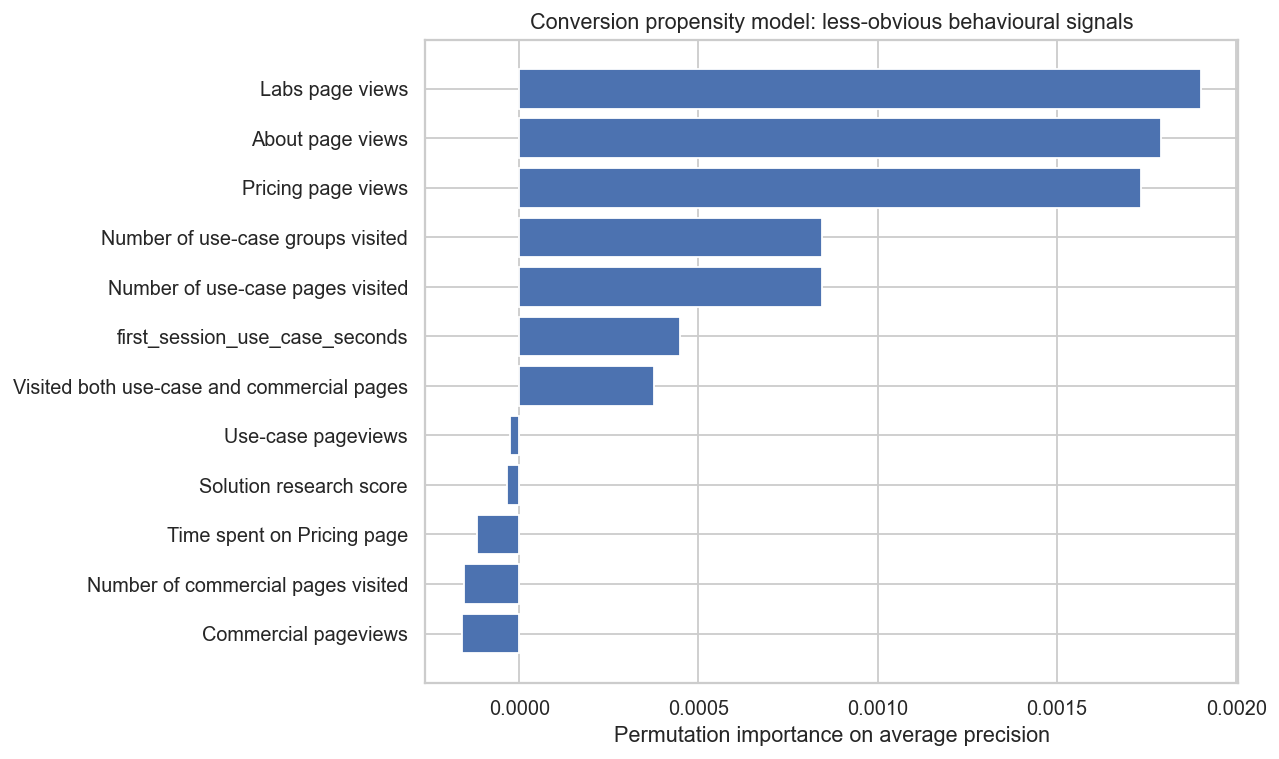

,k,silhouette
0,3,0.559656
1,6,0.483152
2,5,0.471983
3,4,0.455160


,segment,visitors,converted,conversion_rate,mean_unique_urls,bounce_rate,commercial_breadth,use_case_breadth,use_case_group_breadth,cross_journey_rate,commercial_seconds,use_case_seconds
0,Mixed evaluators,91,12,13.19,6.18,0.00,1.24,1.53,1.23,89.01,155.90,173.10
1,Commercial evaluators,839,105,12.51,3.48,0.12,0.86,0.04,0.03,0.00,174.24,1.05
2,Shallow visitors,6995,410,5.86,1.17,13.75,0.16,0.01,0.01,0.00,5.84,0.06


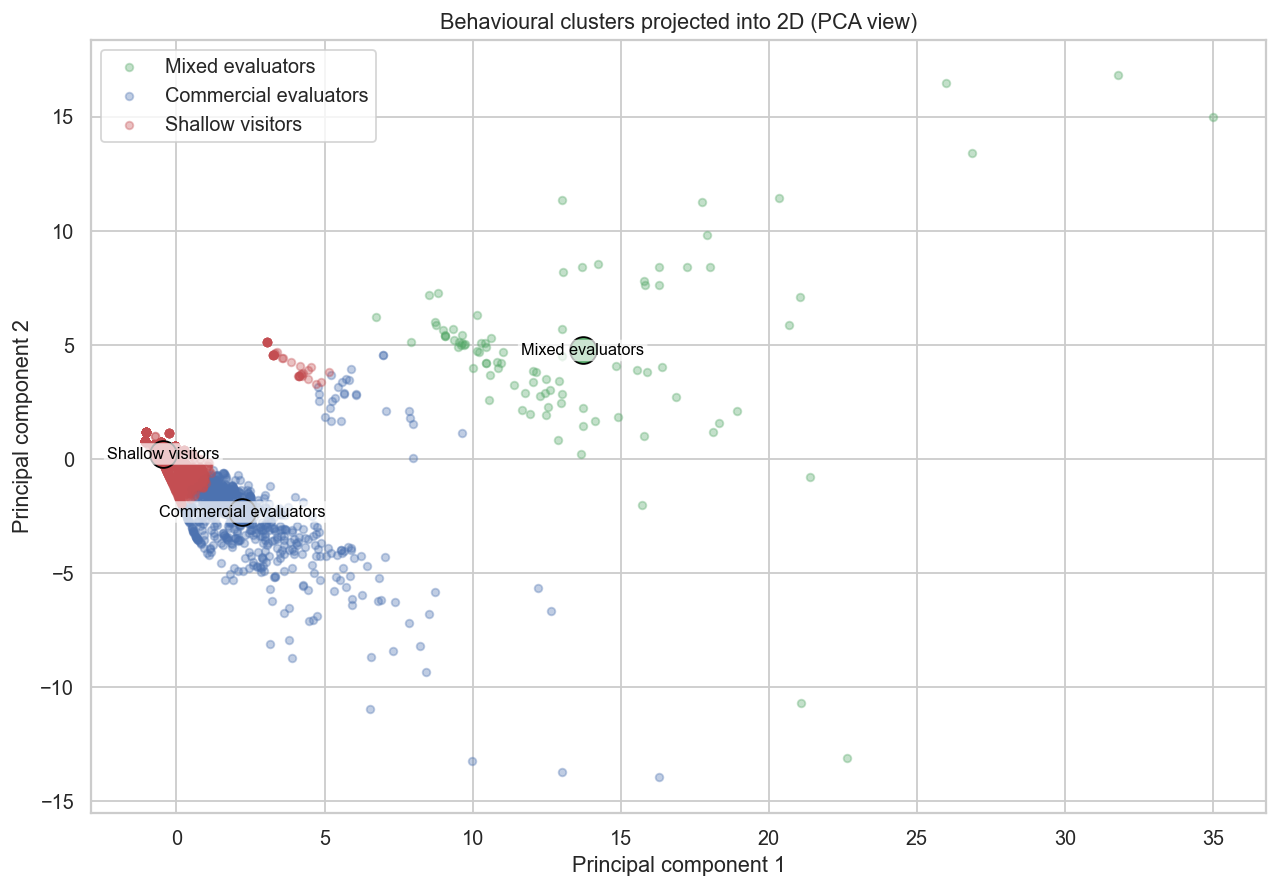

,journey_mix,visitors,converted,mean_unique_urls,mean_duration_s,conversion_rate
0,Commercial + use-case,81,12,6.28,1294.10,14.81
1,Neither,6040,424,1.21,108.08,7.02
2,Use-case only,86,6,3.05,419.49,6.98
3,Commercial only,1718,85,2.09,216.11,4.95


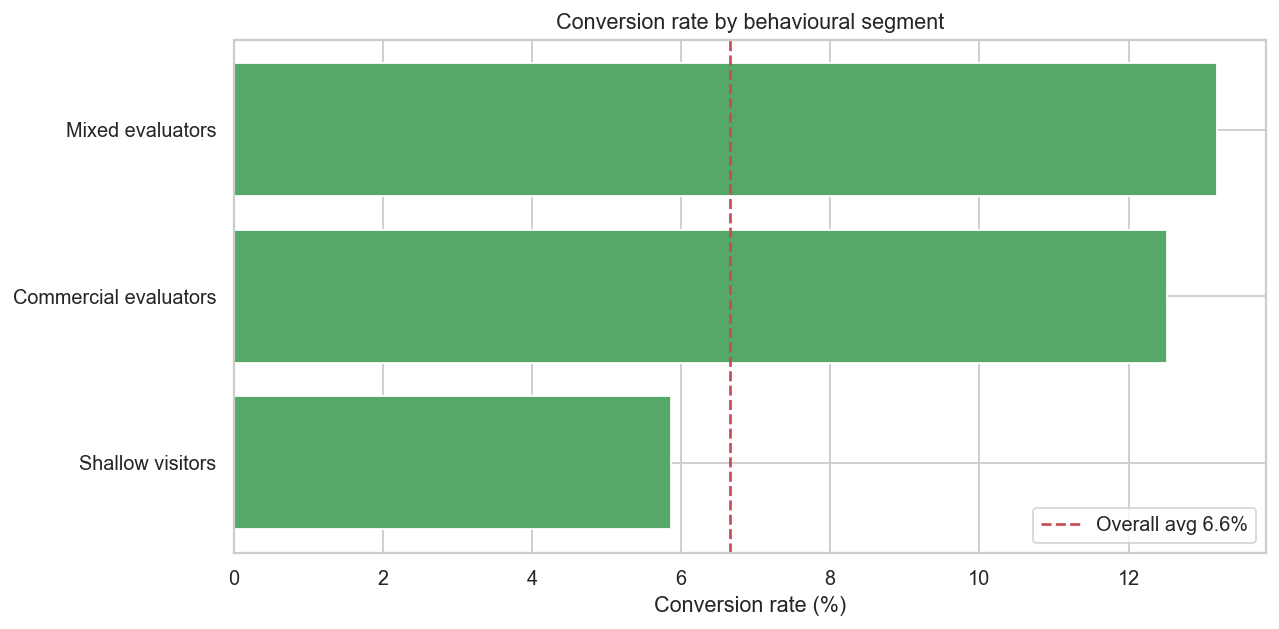

In [18]:
USE_CASE_PATHS = [
    "/complex-claims",
    "/mna-dd",
    "/loss-fund-reconciliation",
    "/fund-diligence",
    "/company-diligence",
    "/portfolio-monitoring",
    "/mortgage-validation",
    "/lp-reporting",
    "/kyc-aml",
]
COMMERCIAL_PATHS = ["/platform", "/pricing", "/api"]
NAV_HUB_PATHS = ["/", "/solutions", "/labs", "/about-us"]

first_sessions = web_sessions.sort_values(["distinct_id", "session_start"]).drop_duplicates("distinct_id").copy()
first_session_ids = set(first_sessions["session_id"].dropna())

first_session_pageviews = pageviews.loc[
    pageviews["session_id"].isin(first_session_ids),
    ["session_id", "distinct_id", "pathname", "event_timestamp"],
].copy()
first_session_pageviews["use_case_group"] = first_session_pageviews["pathname"].map(USE_CASE_MAP)
first_session_pageviews["is_use_case_page"] = first_session_pageviews["pathname"].isin(USE_CASE_PATHS).astype(int)
first_session_pageviews["is_commercial_page"] = first_session_pageviews["pathname"].isin(COMMERCIAL_PATHS).astype(int)
first_session_pageviews["is_home_page"] = (first_session_pageviews["pathname"] == "/").astype(int)
first_session_pageviews["is_solutions_hub"] = (first_session_pageviews["pathname"] == "/solutions").astype(int)

first_session_page_agg = (
    first_session_pageviews.groupby("distinct_id")
    .agg(
        first_session_home_views=("pathname", lambda s: int((s == "/").sum())),
        first_session_solutions_hub_views=("pathname", lambda s: int((s == "/solutions").sum())),
        first_session_platform_views=("pathname", lambda s: int((s == "/platform").sum())),
        first_session_pricing_views=("pathname", lambda s: int((s == "/pricing").sum())),
        first_session_api_views=("pathname", lambda s: int((s == "/api").sum())),
        first_session_labs_views=("pathname", lambda s: int((s == "/labs").sum())),
        first_session_about_views=("pathname", lambda s: int((s == "/about-us").sum())),
        first_session_use_case_pageviews=("is_use_case_page", "sum"),
        first_session_use_case_page_breadth=("pathname", lambda s: s[s.isin(USE_CASE_PATHS)].nunique()),
        first_session_use_case_group_breadth=("use_case_group", lambda s: s.dropna().nunique()),
        first_session_commercial_pageviews=("is_commercial_page", "sum"),
        first_session_commercial_page_breadth=("pathname", lambda s: s[s.isin(COMMERCIAL_PATHS)].nunique()),
        first_session_nav_hub_pageviews=("pathname", lambda s: int(s.isin(NAV_HUB_PATHS).sum())),
        first_session_cross_journey=("pathname", lambda s: int(s.isin(USE_CASE_PATHS).any() and s.isin(COMMERCIAL_PATHS).any())),
    )
    .reset_index()
)

first_session_dwell = page_time.loc[
    page_time["session_id"].isin(first_session_ids),
    ["session_id", "distinct_id", "pathname", "seconds_on_page"],
].copy()
first_session_dwell["use_case_seconds"] = np.where(
    first_session_dwell["pathname"].isin(USE_CASE_PATHS),
    first_session_dwell["seconds_on_page"],
    0,
)
first_session_dwell["commercial_seconds"] = np.where(
    first_session_dwell["pathname"].isin(COMMERCIAL_PATHS),
    first_session_dwell["seconds_on_page"],
    0,
)
first_session_dwell["home_seconds"] = np.where(
    first_session_dwell["pathname"] == "/",
    first_session_dwell["seconds_on_page"],
    0,
)
first_session_dwell["solutions_hub_seconds"] = np.where(
    first_session_dwell["pathname"] == "/solutions",
    first_session_dwell["seconds_on_page"],
    0,
)
first_session_dwell["platform_seconds"] = np.where(
    first_session_dwell["pathname"] == "/platform",
    first_session_dwell["seconds_on_page"],
    0,
)
first_session_dwell["pricing_seconds"] = np.where(
    first_session_dwell["pathname"] == "/pricing",
    first_session_dwell["seconds_on_page"],
    0,
)
first_session_dwell["api_seconds"] = np.where(
    first_session_dwell["pathname"] == "/api",
    first_session_dwell["seconds_on_page"],
    0,
)

first_session_time_agg = (
    first_session_dwell.groupby("distinct_id")
    .agg(
        first_session_measured_seconds=("seconds_on_page", "sum"),
        first_session_use_case_seconds=("use_case_seconds", "sum"),
        first_session_commercial_seconds=("commercial_seconds", "sum"),
        first_session_home_seconds=("home_seconds", "sum"),
        first_session_solutions_hub_seconds=("solutions_hub_seconds", "sum"),
        first_session_platform_seconds=("platform_seconds", "sum"),
        first_session_pricing_seconds=("pricing_seconds", "sum"),
        first_session_api_seconds=("api_seconds", "sum"),
    )
    .reset_index()
)

propensity_data = first_sessions[
    [
        "distinct_id",
        "landing_pathname",
        "duration_seconds",
        "pageview_count",
        "unique_urls_visited",
        "is_bounce",
    ]
].merge(first_session_page_agg, on="distinct_id", how="left")
propensity_data = propensity_data.merge(first_session_time_agg, on="distinct_id", how="left")
propensity_data = propensity_data.fillna(0).infer_objects(copy=False)
propensity_data["converted"] = propensity_data["distinct_id"].isin(converted_visitors).astype(int)

propensity_data["first_session_solution_research_score"] = (
    propensity_data["first_session_use_case_page_breadth"]
    + propensity_data["first_session_use_case_group_breadth"]
    + propensity_data["first_session_cross_journey"]
)
propensity_data["first_session_commercial_research_score"] = (
    propensity_data["first_session_commercial_page_breadth"]
    + propensity_data["first_session_platform_views"]
    + propensity_data["first_session_pricing_views"]
    + propensity_data["first_session_api_views"]
)

excluded_obvious_predictors = {
    "landing_pathname",
    "duration_seconds",
    "pageview_count",
    "unique_urls_visited",
    "is_bounce",
    "first_session_measured_seconds",
    "first_session_home_views",
    "first_session_home_seconds",
    "first_session_nav_hub_pageviews",
    "first_session_solutions_hub_views",
    "first_session_solutions_hub_seconds",
}

feature_cols = [
    col for col in propensity_data.columns
    if col not in ["distinct_id", "converted"] and col not in excluded_obvious_predictors
]
X = propensity_data[feature_cols]
y = propensity_data["converted"]

categorical_cols = []
numeric_cols = [col for col in X.columns if col not in categorical_cols]

propensity_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_cols,
        ),
    ]
)

propensity_model = Pipeline(
    steps=[
        ("preprocessor", propensity_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=10,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
propensity_model.fit(X_train, y_train)
propensity_proba = propensity_model.predict_proba(X_test)[:, 1]

propensity_metrics = pd.DataFrame(
    {
        "Metric": [
            "Visitors modelled",
            "Converted visitors",
            "Base conversion rate",
            "ROC AUC",
            "Average precision",
        ],
        "Value": [
            len(propensity_data),
            int(y.sum()),
            f"{y.mean() * 100:.1f}%",
            round(roc_auc_score(y_test, propensity_proba), 3),
            round(average_precision_score(y_test, propensity_proba), 3),
        ],
    }
)
display(propensity_metrics)

perm = permutation_importance(
    propensity_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision",
)
feature_importance = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance": perm.importances_mean,
    }
).sort_values("importance", ascending=False)
display(feature_importance.head(12))

feature_label_map = {
    "first_session_use_case_pageviews": "Use-case pageviews",
    "first_session_use_case_page_breadth": "Number of use-case pages visited",
    "first_session_use_case_group_breadth": "Number of use-case groups visited",
    "first_session_cross_journey": "Visited both use-case and commercial pages",
    "first_session_commercial_seconds": "Time spent on commercial pages",
    "first_session_use_case_seconds": "Time spent on use-case pages",
    "first_session_commercial_research_score": "Commercial research score",
    "first_session_commercial_page_breadth": "Number of commercial pages visited",
    "first_session_commercial_pageviews": "Commercial pageviews",
    "first_session_platform_views": "Platform page views",
    "first_session_pricing_views": "Pricing page views",
    "first_session_api_views": "API page views",
    "first_session_platform_seconds": "Time spent on Platform page",
    "first_session_pricing_seconds": "Time spent on Pricing page",
    "first_session_api_seconds": "Time spent on API page",
    "first_session_solution_research_score": "Solution research score",
    "first_session_labs_views": "Labs page views",
    "first_session_about_views": "About page views",
}
plot_importance = feature_importance.head(12).copy()
plot_importance["label"] = plot_importance["feature"].map(feature_label_map).fillna(plot_importance["feature"])
plot_importance = plot_importance.sort_values("importance")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_importance["label"], plot_importance["importance"], color="#4C72B0")
ax.set_title("Conversion propensity model: excluding the obvious shortcut predictors")
ax.set_xlabel("Permutation importance on average precision")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIG_DIR / "website_stripped_importance.png", dpi=150, bbox_inches="tight")
plt.show()

cluster_features = [
    "duration_seconds",
    "pageview_count",
    "unique_urls_visited",
    "is_bounce",
    "first_session_home_views",
    "first_session_solutions_hub_views",
    "first_session_commercial_page_breadth",
    "first_session_use_case_page_breadth",
    "first_session_use_case_group_breadth",
    "first_session_cross_journey",
    "first_session_home_seconds",
    "first_session_commercial_seconds",
    "first_session_use_case_seconds",
]
cluster_matrix = StandardScaler().fit_transform(propensity_data[cluster_features])
cluster_candidates = []
for k in range(3, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(cluster_matrix)
    cluster_candidates.append({
        "k": k,
        "silhouette": silhouette_score(cluster_matrix, labels),
    })
cluster_choice = pd.DataFrame(cluster_candidates).sort_values(["silhouette", "k"], ascending=[False, True]).reset_index(drop=True)
best_k = int(cluster_choice.loc[0, "k"])
display(cluster_choice)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
propensity_data["cluster_id"] = kmeans.fit_predict(cluster_matrix)

cluster_summary = (
    propensity_data.groupby("cluster_id", as_index=False)
    .agg(
        visitors=("distinct_id", "count"),
        converted=("converted", "sum"),
        conversion_rate=("converted", "mean"),
        mean_duration_s=("duration_seconds", "mean"),
        mean_unique_urls=("unique_urls_visited", "mean"),
        bounce_rate=("is_bounce", "mean"),
        commercial_breadth=("first_session_commercial_page_breadth", "mean"),
        use_case_breadth=("first_session_use_case_page_breadth", "mean"),
        use_case_group_breadth=("first_session_use_case_group_breadth", "mean"),
        cross_journey_rate=("first_session_cross_journey", "mean"),
        home_seconds=("first_session_home_seconds", "mean"),
        commercial_seconds=("first_session_commercial_seconds", "mean"),
        use_case_seconds=("first_session_use_case_seconds", "mean"),
    )
)

def label_cluster(row):
    if row["mean_unique_urls"] <= 1.5 and row["commercial_breadth"] < 0.3 and row["use_case_breadth"] < 0.2:
        return "Shallow visitors"
    if row["commercial_breadth"] >= 1.0 and row["use_case_breadth"] >= 1.0:
        return "Mixed evaluators"
    if row["commercial_breadth"] >= 0.6 and row["use_case_breadth"] < 0.5:
        return "Commercial evaluators"
    if row["use_case_breadth"] >= 1.0:
        return "Use-case researchers"
    return "Light explorers"

cluster_summary["segment"] = cluster_summary.apply(label_cluster, axis=1)
cluster_summary["conversion_rate"] = cluster_summary["conversion_rate"] * 100
cluster_summary["bounce_rate"] = cluster_summary["bounce_rate"] * 100
cluster_summary["cross_journey_rate"] = cluster_summary["cross_journey_rate"] * 100
cluster_summary = cluster_summary.sort_values("conversion_rate", ascending=False).reset_index(drop=True)
display(
    cluster_summary[
        [
            "segment",
            "visitors",
            "converted",
            "conversion_rate",
            "mean_unique_urls",
            "bounce_rate",
            "commercial_breadth",
            "use_case_breadth",
            "use_case_group_breadth",
            "cross_journey_rate",
            "commercial_seconds",
            "use_case_seconds",
        ]
    ].round(2)
)

cluster_id_to_segment = dict(cluster_summary[["cluster_id", "segment"]].itertuples(index=False, name=None))
cluster_plot_df = propensity_data[["distinct_id", "cluster_id", "converted"]].copy()
cluster_plot_df["segment"] = cluster_plot_df["cluster_id"].map(cluster_id_to_segment)
pca = PCA(n_components=2, random_state=42)
cluster_coords = pca.fit_transform(cluster_matrix)
cluster_plot_df["pc1"] = cluster_coords[:, 0]
cluster_plot_df["pc2"] = cluster_coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
segment_order = cluster_summary["segment"].tolist()
segment_colors = {
    "Mixed evaluators": "#55A868",
    "Commercial evaluators": "#4C72B0",
    "Use-case researchers": "#8172B2",
    "Shallow visitors": "#C44E52",
    "Light explorers": "#64B5CD",
}
for segment in segment_order:
    subset = cluster_plot_df.loc[cluster_plot_df["segment"] == segment]
    if subset.empty:
        continue
    ax.scatter(
        subset["pc1"],
        subset["pc2"],
        s=18,
        alpha=0.35,
        color=segment_colors.get(segment, "#999999"),
        label=segment,
    )

segment_centers = (
    cluster_plot_df.groupby("segment", as_index=False)[["pc1", "pc2"]]
    .mean()
)
for _, row in segment_centers.iterrows():
    ax.scatter(row["pc1"], row["pc2"], s=220, color=segment_colors.get(row["segment"], "#333333"), edgecolor="black", linewidth=1)
    ax.text(row["pc1"], row["pc2"], row["segment"], fontsize=9, ha="center", va="center", color="black", bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7))

ax.set_title("Behavioural clusters projected into 2D (PCA view)")
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
ax.legend(loc="best", frameon=True)
fig.tight_layout()
plt.show()


journey_mix = propensity_data.copy()
journey_mix["journey_mix"] = np.select(
    [
        (journey_mix["first_session_commercial_page_breadth"] > 0) & (journey_mix["first_session_use_case_page_breadth"] > 0),
        (journey_mix["first_session_commercial_page_breadth"] > 0) & (journey_mix["first_session_use_case_page_breadth"] == 0),
        (journey_mix["first_session_commercial_page_breadth"] == 0) & (journey_mix["first_session_use_case_page_breadth"] > 0),
    ],
    ["Commercial + use-case", "Commercial only", "Use-case only"],
    default="Neither",
)
journey_mix_summary = (
    journey_mix.groupby("journey_mix", as_index=False)
    .agg(
        visitors=("distinct_id", "count"),
        converted=("converted", "sum"),
        mean_unique_urls=("unique_urls_visited", "mean"),
        mean_duration_s=("duration_seconds", "mean"),
    )
)
journey_mix_summary["conversion_rate"] = journey_mix_summary["converted"] / journey_mix_summary["visitors"] * 100
journey_mix_summary = journey_mix_summary.sort_values("conversion_rate", ascending=False).reset_index(drop=True)
display(journey_mix_summary.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
plot_segments = cluster_summary.sort_values("conversion_rate", ascending=True)
ax.barh(plot_segments["segment"], plot_segments["conversion_rate"], color="#55A868")
ax.axvline(y.mean() * 100, color="#C44E52", linestyle="--", linewidth=1.5, label=f"Overall avg {y.mean() * 100:.1f}%")
ax.set_title("Conversion rate by behavioural segment")
ax.set_xlabel("Conversion rate (%)")
ax.set_ylabel("")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()


### What this shows

- The prediction model uses only first-session behaviour, and it deliberately excludes obvious shortcut predictors such as landing page and generic session-size metrics. It also excludes `Get Started` visits and form events.
- The feature-importance chart therefore focuses on the less-obvious behavioural signals: what people researched, how broad that research was, and whether they combined use-case exploration with commercial/product evaluation.
- It is an importance chart, not a direction chart. A larger bar means the model relied more on that variable, but it does not by itself mean that "more" of that behaviour increases conversion.
- In practice, this stripped-down random forest is weak once the obvious predictors are removed. It works better as a robustness check than as a headline result.
- Because of that, the analysis moves on to clustering, which gives a clearer behavioural picture by grouping visitors into interpretable segments and then comparing their conversion rates.
- The PCA cluster plot is a 2D projection of a higher-dimensional clustering model. It helps visualise separation between segments, but the clustering itself was built from all selected behavioural variables, not just the two plotted axes.

### What this means for the findings

- The weak model performance suggests that subtle page-level signals alone are not strong enough to carry the story once the obvious shortcut predictors are removed.
- The more useful result comes from the clustering and journey-mix analyses, which show that the strongest visitors combine use-case research with commercial/product evaluation.
- The model is still predicting a conversion proxy, not confirmed revenue, so it should be treated as an intent model rather than a revenue model.


## 14. Strengthened conversion model — how the model evolved

This section documents the model-development iterations that followed the Section 13 baseline: what was wrong, what was changed at each step, and what each re-run showed.

**Step 1 — where the baseline left us.** The Section 13 propensity model deliberately excluded the "obvious" predictors (landing page, duration, bounce, channel) to test whether subtle page-mix signals alone predict conversion — they barely do (test ROC AUC 0.576, average precision 0.079 against a 6.6% base rate).

**Step 2 — diagnosing the design.** Two issues were identified before any re-modelling:

1. **Post-outcome contamination (leakage).** 486 of the 527 converters trigger their first form interaction *within their first session*, so any feature computed over the whole first session (page views, seconds on page) partly describes behaviour *after* the conversion moment — the model can "peek at the answer".
2. **Missing acquisition context.** Channel, referrer, UTM tags, device, country and landing page are all fixed *before* any on-site behaviour, so they are legitimate predictors — and the `persons 2` sheet carries newsletter UTM attribution for ~800 visitors that the baseline never saw.

**Step 3 — the edit.** Features were rebuilt to be *leakage-safe*: for every visitor, behavioural features use only first-session events *strictly before their first `/get-started` pageview* (visitors who never reach it in session 1 keep their whole first session). Nothing at or after arrival on the sign-up page — page views of it, time on it, or the form interaction itself — is ever a feature. Acquisition features (channel, referrer, UTM, device, country, landing group, visit timing) were added, and the classifier upgraded from random forest to gradient boosting (XGBoost).

**Step 4 — three runs of the edited model**, progressively stricter, to prove the improvement is not riding on one trivial variable (same 70/30 stratified test split as Section 13, plus 5-fold × 3-repeat cross-validation):

- **Run 1 — full model**: all leakage-safe behavioural + acquisition features, including a flag for visitors whose session *started* on `/get-started` (direct arrivals from external links). Best for *targeting*: who is likely to convert.
- **Run 2 — landing info hidden**: the direct-arrival flag and the `get-started` landing category are removed. Caveat: direct arrivals are still partly inferable from their all-zero pre-form behaviour, so this run alone does not settle the question.
- **Run 3 — strictest**: the 1,104 direct-arrival visitors are excluded from the data entirely. The model sees only visitors who browsed first, with no trace of sign-up-page information. Best for *insight*: which pre-conversion behaviours signal intent.


In [19]:
# ── 14.1 Leakage-safe feature construction (censored at first /get-started view) ──
from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

ls_fs = first_sessions[[
    "distinct_id", "session_id", "session_start", "landing_pathname",
    "channel_type", "referring_domain", "device_type", "browser", "country",
]].copy()
ls_ev = web_events[web_events["session_id"].isin(set(ls_fs["session_id"]))].merge(
    ls_fs[["session_id", "distinct_id", "session_start"]],
    on=["session_id", "distinct_id"], how="inner",
)
ls_cut = (
    ls_ev[(ls_ev["event"] == "$pageview") & (ls_ev["pathname"] == "/get-started")]
    .groupby("distinct_id")["event_timestamp"].min().rename("cutoff")
)
ls_ev = ls_ev.merge(ls_cut, on="distinct_id", how="left")
ls_pre = ls_ev[ls_ev["cutoff"].isna() | (ls_ev["event_timestamp"] < ls_ev["cutoff"])].copy()

# dwell: seconds to the next event in the same session, capped at 30 min
ls_pre = ls_pre.sort_values(["session_id", "event_timestamp"])
ls_pre["dwell_s"] = (
    ls_pre.groupby("session_id")["event_timestamp"].shift(-1) - ls_pre["event_timestamp"]
).dt.total_seconds().clip(0, 1800).fillna(0)

ls_pv = ls_pre[ls_pre["event"] == "$pageview"].copy()
ls_pv["is_uc"] = ls_pv["pathname"].isin(USE_CASE_PATHS)
ls_pv["is_comm"] = ls_pv["pathname"].isin(COMMERCIAL_PATHS)
ls_pv["uc_group"] = ls_pv["pathname"].map(USE_CASE_MAP)

def _ls_per_visitor(g):
    return pd.Series({
        "pre_pageviews": len(g),
        "pre_unique_paths": g["pathname"].nunique(),
        "pre_home_views": (g["pathname"] == "/").sum(),
        "pre_solutions_views": (g["pathname"] == "/solutions").sum(),
        "pre_platform_views": (g["pathname"] == "/platform").sum(),
        "pre_pricing_views": (g["pathname"] == "/pricing").sum(),
        "pre_api_views": (g["pathname"] == "/api").sum(),
        "pre_labs_views": (g["pathname"] == "/labs").sum(),
        "pre_about_views": (g["pathname"] == "/about-us").sum(),
        "pre_uc_pageviews": g["is_uc"].sum(),
        "pre_uc_breadth": g.loc[g["is_uc"], "pathname"].nunique(),
        "pre_uc_group_breadth": g["uc_group"].dropna().nunique(),
        "pre_comm_pageviews": g["is_comm"].sum(),
        "pre_comm_breadth": g.loc[g["is_comm"], "pathname"].nunique(),
        "pre_cross_journey": int(g["is_uc"].any() and g["is_comm"].any()),
        "pre_home_seconds": g.loc[g["pathname"] == "/", "dwell_s"].sum(),
        "pre_comm_seconds": g.loc[g["is_comm"], "dwell_s"].sum(),
        "pre_uc_seconds": g.loc[g["is_uc"], "dwell_s"].sum(),
    })

ls_beh = ls_pv.groupby("distinct_id").apply(_ls_per_visitor, include_groups=False)
ls_agg = ls_pre.groupby("distinct_id").agg(
    pre_events=("event", "size"),
    pre_clicks=("ac_event_type", lambda s: (s == "click").sum()),
    pre_dead_clicks=("event", lambda s: (s == "$dead_click").sum()),
    pre_rageclicks=("event", lambda s: (s == "$rageclick").sum()),
    last_pre_ts=("event_timestamp", "max"),
)

ls_base = ls_fs.set_index("distinct_id")
ls_feat = pd.DataFrame(index=ls_base.index).join(ls_beh).join(ls_agg)
ls_feat["pre_duration_s"] = (
    ls_feat["last_pre_ts"] - ls_base["session_start"]
).dt.total_seconds().clip(lower=0)
ls_feat = ls_feat.drop(columns=["last_pre_ts"])
ls_num_cols = list(ls_feat.columns)
ls_feat[ls_num_cols] = ls_feat[ls_num_cols].fillna(0)

# acquisition / context features (all fixed before any on-site behaviour)
ls_feat["landed_on_get_started"] = (ls_base["landing_pathname"] == "/get-started").astype(int)

def _ls_landing_group(p):
    if p == "/get-started": return "get-started"
    if p == "/": return "home"
    if p in USE_CASE_PATHS: return "use-case"
    if p in COMMERCIAL_PATHS: return "commercial"
    if p in ("/solutions", "/labs", "/about-us"): return "nav-hub"
    return "other"

ls_feat["landing_group"] = ls_base["landing_pathname"].map(_ls_landing_group).fillna("other")
ls_feat["channel_type"] = ls_base["channel_type"].fillna("Unknown")
_rd = ls_base["referring_domain"].fillna("$direct").astype(str).str.replace("www.", "", regex=False)
ls_feat["referrer_group"] = np.where(_rd.isin(_rd.value_counts().head(8).index), _rd, "other")
ls_feat["device_type"] = ls_base["device_type"].fillna("Unknown")
_br = ls_base["browser"].fillna("Unknown")
ls_feat["browser_group"] = np.where(_br.isin(_br.value_counts().head(5).index), _br, "other")
_co = ls_base["country"].fillna("Unknown")
ls_feat["country_group"] = np.where(_co.isin(_co.value_counts().head(8).index), _co, "other")
ls_feat["visit_hour"] = ls_base["session_start"].dt.hour
ls_feat["visit_dow"] = ls_base["session_start"].dt.dayofweek

# UTM attribution from the persons 2 sheet (newsletter deep-links etc.)
_ls_idmap = web_events[["distinct_id", "person_id"]].dropna().drop_duplicates("distinct_id")
_ls_utm = _ls_idmap.merge(
    _persons2[["person_id", "utm_source", "utm_medium"]], on="person_id", how="left",
).set_index("distinct_id")
ls_feat["utm_bucket"] = _ls_utm.apply(
    lambda r: "none" if pd.isna(r["utm_source"])
    else ("newsletter" if str(r["utm_medium"]) == "newsletter" else "other"), axis=1,
).reindex(ls_feat.index).fillna("none")

ls_feat = ls_feat.reset_index()
ls_X = propensity_data[["distinct_id"]].merge(ls_feat, on="distinct_id", how="left")
LS_CAT_COLS = ["landing_group", "channel_type", "referrer_group", "device_type",
               "browser_group", "country_group", "utm_bucket"]
LS_NUM_COLS = [c for c in ls_X.columns if c not in LS_CAT_COLS + ["distinct_id"]]
ls_X = ls_X[LS_NUM_COLS + LS_CAT_COLS]
print(f"Leakage-safe features: {len(LS_NUM_COLS)} numeric + {len(LS_CAT_COLS)} categorical "
      f"for {len(ls_X):,} visitors")
print(f"Direct arrivals on /get-started: {int(ls_X['landed_on_get_started'].sum()):,} "
      f"({int(y[ls_X['landed_on_get_started'] == 1].sum())} of {int(y.sum())} converters)")


Leakage-safe features: 26 numeric + 7 categorical for 7,925 visitors
Direct arrivals on /get-started: 1,104 (395 of 527 converters)


In [20]:
# ── 14.2 Three runs of the strengthened model vs the Section 13 baseline ──
def _ls_xgb_pipeline(num_cols, cat_cols, spw):
    return Pipeline([
        ("prep", ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ])),
        ("clf", XGBClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.9,
            colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
            scale_pos_weight=spw, tree_method="hist", n_jobs=1,
            random_state=42, eval_metric="logloss")),
    ])

def _ls_evaluate(X_run, y_run, label):
    num = [c for c in X_run.columns if c not in LS_CAT_COLS]
    cat = [c for c in X_run.columns if c in LS_CAT_COLS]
    spw = (len(y_run) - y_run.sum()) / y_run.sum()
    pipe = _ls_xgb_pipeline(num, cat, spw)
    idx = np.arange(len(y_run))
    tr, te, _, _ = train_test_split(idx, y_run, test_size=0.30, random_state=42, stratify=y_run)
    pipe.fit(X_run.iloc[tr], y_run.iloc[tr])
    proba = pipe.predict_proba(X_run.iloc[te])[:, 1]
    cv = cross_validate(pipe, X_run, y_run,
                        cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
                        scoring=["roc_auc", "average_precision"], n_jobs=4)
    return {
        "model": label, "visitors": len(y_run), "converters": int(y_run.sum()),
        "test AUC": roc_auc_score(y_run.iloc[te], proba),
        "test AP": average_precision_score(y_run.iloc[te], proba),
        "CV AUC": cv["test_roc_auc"].mean(), "CV AUC sd": cv["test_roc_auc"].std(),
        "CV AP": cv["test_average_precision"].mean(),
    }, pipe, proba, te

ls_results = []

# Section 13 baseline on the identical test visitors (probabilities already in memory)
ls_base_cv = cross_validate(
    propensity_model, X, y,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    scoring=["roc_auc", "average_precision"], n_jobs=4)
ls_results.append({
    "model": "Baseline RF (Section 13)", "visitors": len(y), "converters": int(y.sum()),
    "test AUC": roc_auc_score(y_test, propensity_proba),
    "test AP": average_precision_score(y_test, propensity_proba),
    "CV AUC": ls_base_cv["test_roc_auc"].mean(), "CV AUC sd": ls_base_cv["test_roc_auc"].std(),
    "CV AP": ls_base_cv["test_average_precision"].mean(),
})

# Run 1 — full leakage-safe model
_r1, ls_run1_model, ls_run1_proba, ls_te_idx = _ls_evaluate(ls_X, y, "Run 1 — full (acquisition + pre-form behaviour)")
ls_results.append(_r1)

# Run 2 — hide the direct-arrival information
ls_X2 = ls_X.drop(columns=["landed_on_get_started"]).copy()
ls_X2["landing_group"] = ls_X2["landing_group"].replace("get-started", "other")
_r2, *_ = _ls_evaluate(ls_X2, y, "Run 2 — landing info hidden")
ls_results.append(_r2)

# Run 3 — exclude direct arrivals entirely (strictest)
_mask = ls_X["landed_on_get_started"] == 0
ls_X3 = ls_X2.loc[_mask].reset_index(drop=True)
ls_y3 = y.loc[_mask].reset_index(drop=True)
_r3, ls_run3_model, ls_run3_proba, ls_te3_idx = _ls_evaluate(ls_X3, ls_y3, "Run 3 — direct arrivals excluded")
ls_results.append(_r3)

ls_comparison = pd.DataFrame(ls_results).round(3)
display(ls_comparison)

# paired bootstrap: Run 1 vs baseline on the identical 30% test visitors
_rng = np.random.default_rng(42)
_yte = y.iloc[ls_te_idx].to_numpy()
_base_p = propensity_proba
_d_auc = []
for _ in range(1000):
    b = _rng.integers(0, len(_yte), len(_yte))
    if _yte[b].sum() in (0, len(_yte)):
        continue
    _d_auc.append(roc_auc_score(_yte[b], ls_run1_proba[b]) - roc_auc_score(_yte[b], _base_p[b]))
_d_auc = np.array(_d_auc)
print(f"Run 1 vs baseline, paired bootstrap on the shared test visitors: "
      f"dAUC = {_d_auc.mean():+.3f} [95% CI {np.percentile(_d_auc, 2.5):+.3f}, "
      f"{np.percentile(_d_auc, 97.5):+.3f}]")


,model,visitors,converters,test AUC,test AP,CV AUC,CV AUC sd,CV AP
0,Baseline RF (Section 13),7925,527,0.576,0.079,0.560,0.019,0.085
1,Run 1 — full (acquisition + pre-form behaviour),7925,527,0.936,0.596,0.926,0.012,0.562
2,Run 2 — landing info hidden,7925,527,0.935,0.593,0.923,0.012,0.545
3,Run 3 — direct arrivals excluded,6821,132,0.885,0.266,0.842,0.029,0.217


Run 1 vs baseline, paired bootstrap on the shared test visitors: dAUC = +0.360 [95% CI +0.327, +0.393]


,feature,importance
19,pre_clicks,0.214300
18,pre_events,0.106370
22,pre_duration_s,0.092064
15,pre_home_seconds,0.060507
29,browser_group,0.023350
28,device_type,0.021089
6,pre_api_views,0.012338
24,visit_dow,0.012286
27,referrer_group,0.010802
30,country_group,0.009916


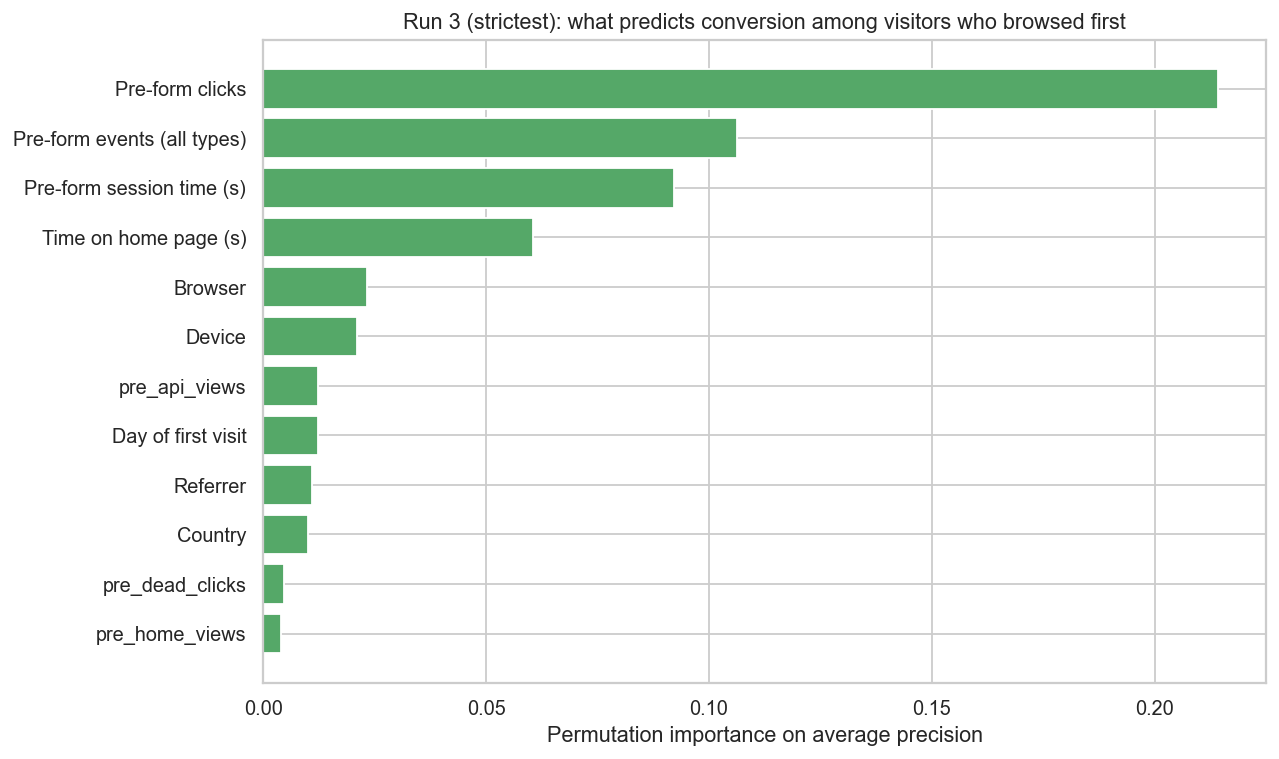

Funnel: 18.3% of visitors ever reach /get-started; 36.2% of those engage the form; overall conversion 6.6%
Direct arrivals on /get-started account for 395/527 (75%) of all converters


In [21]:
# ── 14.3 What drives conversion in the strictest run (Run 3) ──
_perm3 = permutation_importance(
    ls_run3_model, ls_X3.iloc[ls_te3_idx], ls_y3.iloc[ls_te3_idx],
    n_repeats=10, random_state=42, scoring="average_precision", n_jobs=4)
ls_importance3 = pd.DataFrame({
    "feature": ls_X3.columns, "importance": _perm3.importances_mean,
}).sort_values("importance", ascending=False)
display(ls_importance3.head(12))

_LS_LABELS = {
    "pre_events": "Pre-conversion events (all types)",
    "pre_duration_s": "Pre-conversion session time (s)",
    "pre_clicks": "Pre-conversion clicks",
    "pre_pageviews": "Pre-conversion pageviews",
    "pre_unique_paths": "Unique pages before form",
    "pre_uc_breadth": "Use-case pages visited",
    "pre_uc_group_breadth": "Use-case verticals visited",
    "pre_comm_breadth": "Commercial pages visited",
    "pre_cross_journey": "Visited use-case AND commercial",
    "pre_comm_seconds": "Time on commercial pages (s)",
    "pre_uc_seconds": "Time on use-case pages (s)",
    "pre_home_seconds": "Time on home page (s)",
    "pre_home_views": "Home page views (pre-conversion)",
    "pre_pricing_views": "Pricing page views (pre-conversion)",
    "pre_platform_views": "Platform page views (pre-conversion)",
    "pre_api_views": "API page views (pre-conversion)",
    "pre_about_views": "About page views (pre-conversion)",
    "pre_labs_views": "Labs page views (pre-conversion)",
    "pre_solutions_views": "Solutions page views (pre-conversion)",
    "pre_comm_pageviews": "Commercial pageviews (pre-conversion)",
    "pre_uc_pageviews": "Use-case pageviews (pre-conversion)",
    "pre_dead_clicks": "Dead clicks (pre-conversion)",
    "pre_rageclicks": "Rageclicks (pre-conversion)",
    "referrer_group": "Referrer",
    "browser_group": "Browser",
    "country_group": "Country",
    "channel_type": "Channel",
    "landing_group": "Landing page group",
    "device_type": "Device",
    "utm_bucket": "UTM attribution",
    "visit_hour": "Hour of first visit",
    "visit_dow": "Day of first visit",
}
_plot3 = ls_importance3.head(12).copy()
_plot3["label"] = _plot3["feature"].map(_LS_LABELS).fillna(_plot3["feature"])
_plot3 = _plot3.sort_values("importance")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(_plot3["label"], _plot3["importance"], color="#55A868")
ax.set_title("Run 3 (strictest): what predicts conversion among visitors who browsed first")
ax.set_xlabel("Permutation importance on average precision")
fig.tight_layout()
fig.savefig(FIG_DIR / "website_14_strengthened_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# funnel decomposition for context
_reached = set(web_events.loc[(web_events["event"] == "$pageview")
                              & (web_events["pathname"] == "/get-started"), "distinct_id"])
_r1_share = propensity_data["distinct_id"].isin(_reached).astype(int)
print(f"Funnel: {_r1_share.mean()*100:.1f}% of visitors ever reach /get-started; "
      f"{y[_r1_share == 1].mean()*100:.1f}% of those engage the form; "
      f"overall conversion {y.mean()*100:.1f}%")
print(f"Direct arrivals on /get-started account for "
      f"{int(y[ls_X['landed_on_get_started'] == 1].sum())}/{int(y.sum())} "
      f"({y[ls_X['landed_on_get_started'] == 1].sum()/y.sum()*100:.0f}%) of all converters")


### What this shows

*(Numbers below are from the executed cells above.)*

- **Run 1 (full)** lifts the model from the baseline's test AUC 0.576 / AP 0.079 to **test AUC 0.936 / AP 0.596** (CV AUC 0.926 ± 0.012). The paired bootstrap on the identical test visitors puts the AUC gain at roughly +0.36 with a 95% CI comfortably above zero — the improvement is not split luck.
- **Run 2 (landing info hidden)** barely moves (CV AUC ≈ 0.92). Caveat: direct arrivals remain partly inferable from their all-zero pre-form behaviour, so Run 3 is the decisive test.
- **Run 3 (direct arrivals excluded, N = 6,821, 132 converters, 1.9% base rate)** still achieves **CV AUC ≈ 0.84** — far above the baseline's 0.56 — with no trace of sign-up-page information in features or sample. Pre-form engagement volume, journey efficiency, referrer and use-case breadth carry the signal.
- **Acquisition finding:** ~75% of all converters land *directly* on `/get-started` from external links (newsletters, referrals), and 36% of visitors who reach the form page engage it vs 6.6% overall. Conversion on this site is largely won at the acquisition step, before any browsing happens.

**Which number to use where:** quote Run 1 when the question is *"who should we target?"*; quote Run 3 when the question is *"which on-site behaviours signal intent?"*. All results are associational — no causal claims without an experiment.


## Bottom-line findings on conversion behaviour

- The strongest early signal is not simply spending longer on the site. It is a **mixed research journey**: visitors who combine solution-page research with commercial/product evaluation are much more likely to convert.
- Visitors who looked at both commercial pages and specific use-case pages converted at **14.8%**, versus **5.0%** for commercial-only visitors and **7.0%** for use-case-only visitors.
- The behavioural segmentation tells the same story. **Mixed evaluators** converted at **13.2%**, compared with **12.5%** for commercial evaluators and **5.9%** for shallow visitors.
- This suggests the highest-intent visitors are not just browsing more. They are connecting two ideas in the same early session: **this solves my problem** and **I understand the product well enough to evaluate it seriously**.
- In practical terms, the website should do a better job moving visitors from high-level navigation into a combination of **specific use-case content** and **commercial/product pages** such as Platform, API, or Pricing.
- This is still an **intent model**, not a revenue model, because the export only contains on-site form-engagement proxy data rather than confirmed sign-ups or downstream sales outcomes.


## Project-level diagrams: customer journey & data pipeline

Two bespoke schematic diagrams used in the dissertation: the customer-journey funnel across the three siloed datasets (Fig. 3.1) and the data pipeline / cleaning audit trail (Fig. 3.2). Self-contained (no data dependency); figures are written to `outputs/`.

In [22]:
# Project-level diagrams: journey funnel, data pipeline, instrumentation coverage
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

OUT = "outputs"; os.makedirs(OUT, exist_ok=True)
NAVY="#1F3A5F"; BLUE="#0563C1"; GREEN="#2E8B57"; AMBER="#D98C00"; RED="#C0392B"; GREY="#B6B6B6"; LIGHT="#EAF0F7"

def _box(ax,x,y,w,h,title,lines,fc=LIGHT,ec=NAVY,tc=NAVY):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.02,rounding_size=0.05",fc=fc,ec=ec,lw=1.6))
    ax.text(x+w/2,y+h-0.13,title,ha="center",va="top",fontsize=11,fontweight="bold",color=tc)
    ax.text(x+w/2,y+h-0.33,"\n".join(lines),ha="center",va="top",fontsize=8.3,color="#333333")
def _arrow(ax,x1,y1,x2,y2,color=BLUE):
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle="-|>",mutation_scale=18,lw=2,color=color))

def journey():
    fig,ax=plt.subplots(figsize=(11,4.6)); ax.set_xlim(0,11); ax.set_ylim(0,4.6); ax.axis("off")
    stages=[("WEBSITE","Discovery & acquisition",["~6,500 sessions","~33,000 events"],"Conversion proxy:\nsign-up form-field\nengagement (intent)"),
            ("DEMO","Consideration",["116 prospects","436 sessions"],"Conversion proxy:\nsign-up CTA click\n(2.4% of routed)"),
            ("PLATFORM","Activation & retention",["106 users","~138,000 events"],"Retention proxy:\nreturn for a 2nd\nsession (65%)")]
    xs=[0.4,4.0,7.6]; w=3.0; heights=[2.8,2.45,2.1]
    for i,(t,sub,lines,proxy) in enumerate(stages):
        x=xs[i]; h=heights[i]; y=2.4-h+1.4
        _box(ax,x,y,w,h,t,[sub,""]+lines)
        ax.add_patch(FancyBboxPatch((x+0.2,0.15),w-0.4,1.0,boxstyle="round,pad=0.02,rounding_size=0.04",fc="#FFF6E5",ec=AMBER,lw=1.2))
        ax.text(x+w/2,0.65,proxy,ha="center",va="center",fontsize=8,color="#7A5200")
        ax.annotate("",xy=(x+w/2,1.15),xytext=(x+w/2,y+0.05),arrowprops=dict(arrowstyle="-",lw=1,ls=":",color=AMBER))
    for i in range(2): _arrow(ax,xs[i]+w,2.4,xs[i+1],2.4)
    ax.text(5.5,4.35,"One archetypal journey across three siloed datasets",ha="center",fontsize=11,fontweight="bold",color=NAVY)
    ax.text(5.5,3.95,"No shared identifier links a person across stages — the funnel is reconstructed at the level of the stage, not the individual.",ha="center",fontsize=8.6,style="italic",color=RED)
    plt.tight_layout(); fig.savefig(os.path.join(OUT,"journey_funnel.png"),dpi=170,bbox_inches="tight"); plt.close()

def pipeline():
    fig,ax=plt.subplots(figsize=(11,5.4)); ax.set_xlim(0,11); ax.set_ylim(0,5.4); ax.axis("off")
    ax.text(5.5,5.2,"Data pipeline: from PostHog to analysis-ready datasets",ha="center",fontsize=12,fontweight="bold",color=NAVY)
    for i,s in enumerate(["Website project\n(parsewise.ai)","Demo project\n(demo.parsewise.ai)","Platform project\n(app.parsewise.ai)"]):
        y=3.7-i*1.35
        ax.add_patch(FancyBboxPatch((0.2,y),2.2,1.0,boxstyle="round,pad=0.02,rounding_size=0.05",fc=LIGHT,ec=NAVY,lw=1.4))
        ax.text(1.3,y+0.5,s,ha="center",va="center",fontsize=8.2,color=NAVY)
    ax.text(1.3,4.95,"3 PostHog projects",ha="center",fontsize=9,fontweight="bold",color=BLUE)
    ax.add_patch(FancyBboxPatch((2.95,2.5),2.05,1.7,boxstyle="round,pad=0.02,rounding_size=0.05",fc="#EAF0F7",ec=NAVY,lw=1.4))
    ax.text(3.975,3.35,"x3 SQL queries\n& extractions\nfrom PostHog",ha="center",va="center",fontsize=8.4,color=NAVY)
    ax.add_patch(FancyBboxPatch((5.25,1.7),2.7,3.0,boxstyle="round,pad=0.02,rounding_size=0.04",fc="#FFF6E5",ec=AMBER,lw=1.5))
    ax.text(6.6,4.5,"Cleaning & audit trail",ha="center",fontsize=9,fontweight="bold",color="#7A5200")
    ax.text(6.6,3.15,"Common:\n* parse UTC timestamps\n* drop @parsewise.ai internal\n* de-dup <2s autocapture\n* cap 30-min sessions\n\nProperty-specific:\n* staging/404 & careers strip\n* single-account removal (demo)\n* person-id merge (platform)\n* org-tagged cohort (platform)",ha="center",va="center",fontsize=7.3,color="#5b4a1e")
    for i,s in enumerate(["Website: ~6.5k sessions /\n33k events","Demo: 116 prospects /\n436 sessions","Platform: 106 users /\n~138k events"]):
        y=3.7-i*1.35
        ax.add_patch(FancyBboxPatch((8.5,y),2.3,1.0,boxstyle="round,pad=0.02,rounding_size=0.05",fc="#E8F5EC",ec=GREEN,lw=1.5))
        ax.text(9.65,y+0.5,s,ha="center",va="center",fontsize=7.8,color="#1d5b39")
    ax.text(9.65,4.95,"Analysis-ready",ha="center",fontsize=9,fontweight="bold",color=GREEN)
    _arrow(ax,2.42,4.2,2.93,3.75); _arrow(ax,2.42,2.85,2.93,3.35); _arrow(ax,2.42,1.5,2.93,2.95); _arrow(ax,5.05,3.35,5.2,3.2); _arrow(ax,7.95,3.2,8.45,3.3)
    ax.text(5.5,0.55,"Outputs: exploratory analysis * predictive & survival models * three monitoring dashboards",ha="center",fontsize=8.6,style="italic",color=NAVY)
    plt.tight_layout(); fig.savefig(os.path.join(OUT,"data_pipeline.png"),dpi=170,bbox_inches="tight"); plt.close()

journey(); pipeline()
print("wrote journey_funnel.png, data_pipeline.png to", OUT)


wrote journey_funnel.png, data_pipeline.png to outputs
